##**Name - Varul Demta**
##**Student-ID: 24291194**


# IS41070 Project -  Predicting Diabetes Risk Using Health Survey Data

(Binary Classification)

Diabetes is a global health issue with rising prevalence and significant implications for both individuals and healthcare systems. Determining high-risk individuals early on is crucial for preventive action as well as treatment at the appropriate time. Traditional screening uses clinical tests, which may be time-consuming, costly or not available to millions of people.

The current project will create a prediction model from indicators of self-rated health using 2015 U.S. Behavioral Risk Factor Surveillance System (BRFSS)dataset. We aim to accurately classify a person as diabetic or not diabetic with characteristics like BMI, general perception of health, mental as well as physical health, lifestyle behavior (e.g., whether they smoke, drink, diet, exercise), as well as medical care access.

A structured workflow of machine learning is followed which consists of understanding the data, performing Exploratory Data Analysis(EDA), preparing data for model training, extensive model evaluation and error comparison to select the best performing model which can identify patterns that helps distinguish high-risk individuals. The result is a binary classification tool which supports public health initiatives of enabling large-scale, non-invasive diabetes risk assessment. With such tools, we can guide our efforts in outreach, preventive strategy and eventually reduction of diabetes

# Task 1: Data Understanding

## 1.1 Dataset Introduction

For this project, I made use a publicly available dataset from Behavioral Risk Factor Surveillance System(**BRFSS**) 2015 through Kaggle. BRFSS is a health-related telephone survey conducted by the CDC(Centers for Disease Control and Prevention) to collect data from U.S citizens with regards to their daily-life activities, any existing chronic conditions and use of any sort of precautionary measures.

The dataset used contains a balanced sample of **70692 rows**, that is divided equally among individuals diagnosed with diabetes and those without. It has **21 feature columns** which contained responses according to the self-reported answers to the questions asked.

The feature variables are:
1. Physiological indicators like **BMI** (Body Mass Index), age and Gender.
2. Health history including prior heart disease or stroke.
3. Lifestyle factors such as smoking, alcohol consumption, physical activity and Income.
4. Healthcare access and dietary habits.
5. Mental and physical health conditions over the past 30 days

**Diabetes_binary** is the target variable as such:
1. 0 for individuals non-diabetic.
2. 1 for individuals diabetic.

Therefore this dataset is suitable for performing the **binary classification** task, in which our objective is to predict whether a person is likely to have diabetes based on their self-reported health and lifestyle indicators. With the target variable having a balanced distribution, it is ideal for training and evaluation of classification models without needing for excessive resampling or weighted adjustments.

Link for dataset -> (https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset)

In [9]:
# Main libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set global random seed for reproducibility
np.random.seed(42)

# Scikit-learn model selection & preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Metrics & evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# Others
from sklearn.exceptions import NotFittedError
from scipy.stats import uniform, randint


In [10]:
# Load dataset
diabetes_df = pd.read_csv("diabetes.csv")

# Preview the first few rows
diabetes_df.head()


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


Getting information about the number of rows and columns in the dataset

In [11]:
#Shape and general information
diabetes_df.info()
print("\n")
diabetes_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

(70692, 22)

Checking for target column and its distrubution

In [12]:
#Displaying column names
print("Columns present in this dataset: ",diabetes_df.columns.tolist())

#Target Column is Diabetes_binary , so we are going to check the distribution
target_count = diabetes_df["Diabetes_binary"].value_counts()
distribution_percent = diabetes_df["Diabetes_binary"].value_counts(normalize=True)*100

print("Target class Distribution:\t", target_count)
print("\n")
print("Distribution of target class:\t", distribution_percent)

Columns present in this dataset:  ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Target class Distribution:	 Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


Distribution of target class:	 Diabetes_binary
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64


##1.Data Quality Check & Cleaning

1. Checking data types of columns

In [13]:
#Getting to know the data types of each column
diabetes_df.dtypes

,0
Diabetes_binary,float64
HighBP,float64
HighChol,float64
CholCheck,float64
BMI,float64
Smoker,float64
Stroke,float64
HeartDiseaseorAttack,float64
PhysActivity,float64
Fruits,float64


In [14]:
#Finding rows NaN values to help in easier conversion from float to int datatype
diabetes_df[diabetes_df.isna().any(axis=1)]


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income


There are only 3 NaN values which are all together in row number 46767. So if we drop them it is not going to affect the process.

In [15]:
#Dropping the row with the NaN values and confirming it
diabetes_df = diabetes_df.dropna()
diabetes_df[diabetes_df.isna().any(axis=1)]

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income


In [16]:
#Now converting all the datatype from float to int
diabetes_df = diabetes_df.astype(int)
diabetes_df.dtypes


,0
Diabetes_binary,int64
HighBP,int64
HighChol,int64
CholCheck,int64
BMI,int64
Smoker,int64
Stroke,int64
HeartDiseaseorAttack,int64
PhysActivity,int64
Fruits,int64


2. Check for missing or null values

In [17]:
#Checking for missing values
diabetes_df.isnull().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


No missing or null values are seen.

3.Checking for Duplicate or Constant columns

In [18]:
#Checking for Constant or Duplicate columns
const_cols = [c for c in diabetes_df.columns if diabetes_df[c].nunique() ==1 ]
print("Constant Columns: ",const_cols)

Constant Columns:  []


All columns have more than one unique value hence there are no constant columns.

4. Checking for duplicated rows

In [19]:
#Check for duplicate rows
dup_count = diabetes_df.duplicated().sum()
print("No of duplicated rows: ", dup_count)

No of duplicated rows:  1635


In [20]:
#Dropping duplicates
diabeters_df_no_duplicate = diabetes_df.drop_duplicates().reset_index(drop=True)
diabeters_df_no_duplicate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69057 entries, 0 to 69056
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Diabetes_binary       69057 non-null  int64
 1   HighBP                69057 non-null  int64
 2   HighChol              69057 non-null  int64
 3   CholCheck             69057 non-null  int64
 4   BMI                   69057 non-null  int64
 5   Smoker                69057 non-null  int64
 6   Stroke                69057 non-null  int64
 7   HeartDiseaseorAttack  69057 non-null  int64
 8   PhysActivity          69057 non-null  int64
 9   Fruits                69057 non-null  int64
 10  Veggies               69057 non-null  int64
 11  HvyAlcoholConsump     69057 non-null  int64
 12  AnyHealthcare         69057 non-null  int64
 13  NoDocbcCost           69057 non-null  int64
 14  GenHlth               69057 non-null  int64
 15  MentHlth              69057 non-null  int64
 16  Phys

In [21]:
#Comparing row counts
original_rows = diabetes_df.shape[0]
cleaned_rows = diabeters_df_no_duplicate.shape[0]

removal_percent = (original_rows - cleaned_rows)/(original_rows)*100
print(f"{removal_percent: .2f}% of original rows were removed")

 2.31% of original rows were removed


In [22]:
#Checking the class balance before and after cleaning
print("Before duplication")
print(diabetes_df['Diabetes_binary'].value_counts(normalize=True) * 100)

print("After duplication")
print(diabeters_df_no_duplicate['Diabetes_binary'].value_counts(normalize=True) * 100)

Before duplication
Diabetes_binary
0    50.0
1    50.0
Name: proportion, dtype: float64
After duplication
Diabetes_binary
1    50.823233
0    49.176767
Name: proportion, dtype: float64


There is a very slight in balance of target class which is 0.82% change.

Now comparing descriptive stats of original dataframe and dataframe after removing duplicate rows

In [23]:
#Comparing  Desriptive stats
diabetes_df.describe().T[['mean', 'std','max','min']].join(diabeters_df_no_duplicate.describe().T[['mean', 'std','max','min']], lsuffix='_before', rsuffix='_after')


,mean_before,std_before,max_before,min_before,mean_after,std_after,max_after,min_after
Diabetes_binary,0.500000,0.500004,1.0,0.0,0.508232,0.499936,1.0,0.0
HighBP,0.563458,0.495960,1.0,0.0,0.571224,0.494905,1.0,0.0
HighChol,0.525703,0.499342,1.0,0.0,0.531329,0.499021,1.0,0.0
CholCheck,0.975259,0.155336,1.0,0.0,0.974803,0.156723,1.0,0.0
BMI,29.856985,7.113954,98.0,12.0,29.955834,7.147972,98.0,12.0
Smoker,0.475273,0.499392,1.0,0.0,0.481935,0.499677,1.0,0.0
Stroke,0.062171,0.241468,1.0,0.0,0.063643,0.244118,1.0,0.0
HeartDiseaseorAttack,0.147810,0.354914,1.0,0.0,0.150875,0.357930,1.0,0.0
PhysActivity,0.703036,0.456924,1.0,0.0,0.696483,0.459780,1.0,0.0
Fruits,0.611795,0.487345,1.0,0.0,0.605659,0.488712,1.0,0.0


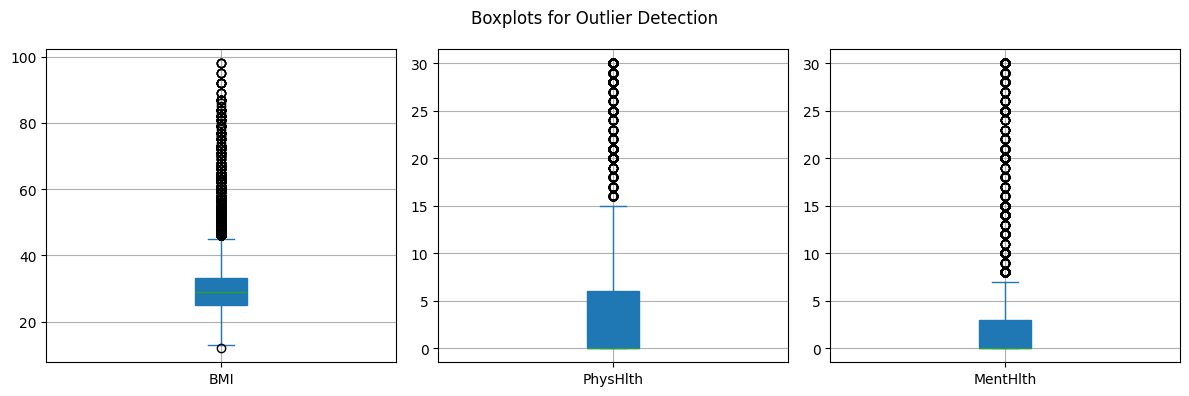

In [24]:
# Boxplots for continuous features
continuous_cols = ['BMI', 'PhysHlth', 'MentHlth']

diabeters_df_no_duplicate[continuous_cols].plot(kind='box', subplots=True, layout=(1, 3), figsize=(12, 4), grid=True, patch_artist=True)
plt.suptitle("Boxplots for Outlier Detection")
plt.tight_layout()
plt.show()


Outliers noticed in the boxplots:
1. Many values of BMI are beyond 60%-70% which is physiologically impossible.
2. PhysHlth and MentHlth are skewed and this is expected since it is capped at 30 days.

Handling of outliers:
1. For BMI extreme values are capped since they lie outside human physiological limits.
2. FOr PhysHlth and MentHlth skewness is acceptable as it is by design.

In [25]:
#Capping BMI outliers using IQR capping
Q1 = diabeters_df_no_duplicate['BMI'].quantile(0.25)
Q3 = diabeters_df_no_duplicate['BMI'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

diabeters_df_no_duplicate['BMI_capped'] = diabeters_df_no_duplicate['BMI'].clip(lower=lower_limit, upper=upper_limit)


In [26]:
#TO check whether the column BMI_capped has been added properly
diabeters_df_no_duplicate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69057 entries, 0 to 69056
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Diabetes_binary       69057 non-null  int64
 1   HighBP                69057 non-null  int64
 2   HighChol              69057 non-null  int64
 3   CholCheck             69057 non-null  int64
 4   BMI                   69057 non-null  int64
 5   Smoker                69057 non-null  int64
 6   Stroke                69057 non-null  int64
 7   HeartDiseaseorAttack  69057 non-null  int64
 8   PhysActivity          69057 non-null  int64
 9   Fruits                69057 non-null  int64
 10  Veggies               69057 non-null  int64
 11  HvyAlcoholConsump     69057 non-null  int64
 12  AnyHealthcare         69057 non-null  int64
 13  NoDocbcCost           69057 non-null  int64
 14  GenHlth               69057 non-null  int64
 15  MentHlth              69057 non-null  int64
 16  Phys

For EDA, we will proceed with the original BMI values to understand the distribution, outlier behaviour and correlation with target variable.

For Modeling purposes we will be using the capped BMI values to mitigate outliers effect in model training. So we will save the clean dataframe which contains the BMI_capped with capped BMI values and drop the old BMI column as it has become redundant.

This will allow us to retain most of the original information while improving the robustness of the model.

In [27]:
#Dropping BMI column from the cleaned dataframe since it is a redundant column now
diabeters_df_no_duplicate.drop('BMI', axis=1, inplace=True)
diabeters_df_no_duplicate.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'BMI_capped'],
      dtype='object')

In [28]:
#Saving the cleaned data to a csv file to use for modeling.
diabeters_df_no_duplicate.to_csv("diabetes_clean_bmi_capped.csv", index=False)
print("Dataset for model training has been saved")

Dataset for model training has been saved


##2.Exploratory Data Analysis(EDA)

In this section, we examine the features in the dataset to understand their statistical properties and distribution. This helps identify which features are continuous vs categorical, spot any skewness or irregularities, and assess their potential influence on the prediction task.


describe() provides summary statistics for all numeric columns, such as mean, standard deviation, and quartiles

In [29]:
diabetes_df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,...,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,...,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,...,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [30]:
# Count of unique values in each column
diabeters_df_no_duplicate.nunique().sort_values()


,0
Diabetes_binary,2
HighBP,2
HighChol,2
CholCheck,2
Smoker,2
Stroke,2
HeartDiseaseorAttack,2
PhysActivity,2
Fruits,2
Veggies,2


This helps distinguish:

Binary columns (with 2 unique values)

Categorical/ordinal features (few unique values)

Continuous/numeric features (many unique values)

##3.Visualizations of relationships

####1.Barplot Distributions of Continuous Features

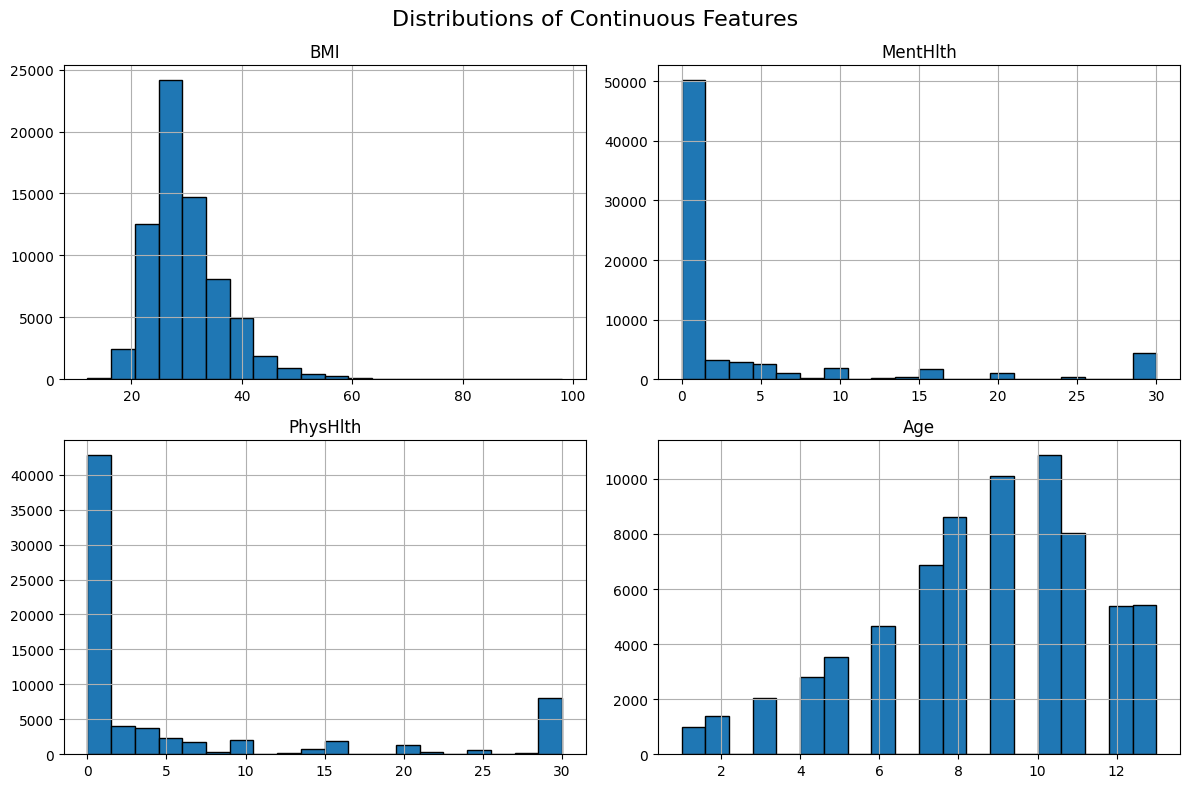

In [31]:
#Code for plot
continuous_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age']

# Histograms
diabetes_df[continuous_cols].hist(bins=20, figsize=(12, 8), edgecolor='black')
plt.suptitle("Distributions of Continuous Features", fontsize=16)
plt.tight_layout()
plt.show()

The above is a plot for displaying the distribution of key Continuous features across the dataset.

Key takeaways:

1. Features such as Mental Health and Physical Health are right-skewed due to the presence of many zeros.
2. BMI is well distributed which shows potential as a strong independent feature.
3. Mental and Physical may require transformation or grouping.
4. Due to ordinal encoding of Age feature, it is not a real continuous variable.


####2.Bar plot showing distribution of binary/categorical features vs Diabetes_binary

/tmp/ipython-input-32-4146093232.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=diabetes_df, x=col, ax=axes[i], palette="Set2")
/tmp/ipython-input-32-4146093232.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=diabetes_df, x=col, ax=axes[i], palette="Set2")
/tmp/ipython-input-32-4146093232.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=diabetes_df, x=col, ax=axes[i], palette="Set2")
/tmp/ipython-input-32-4146093232.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be rem

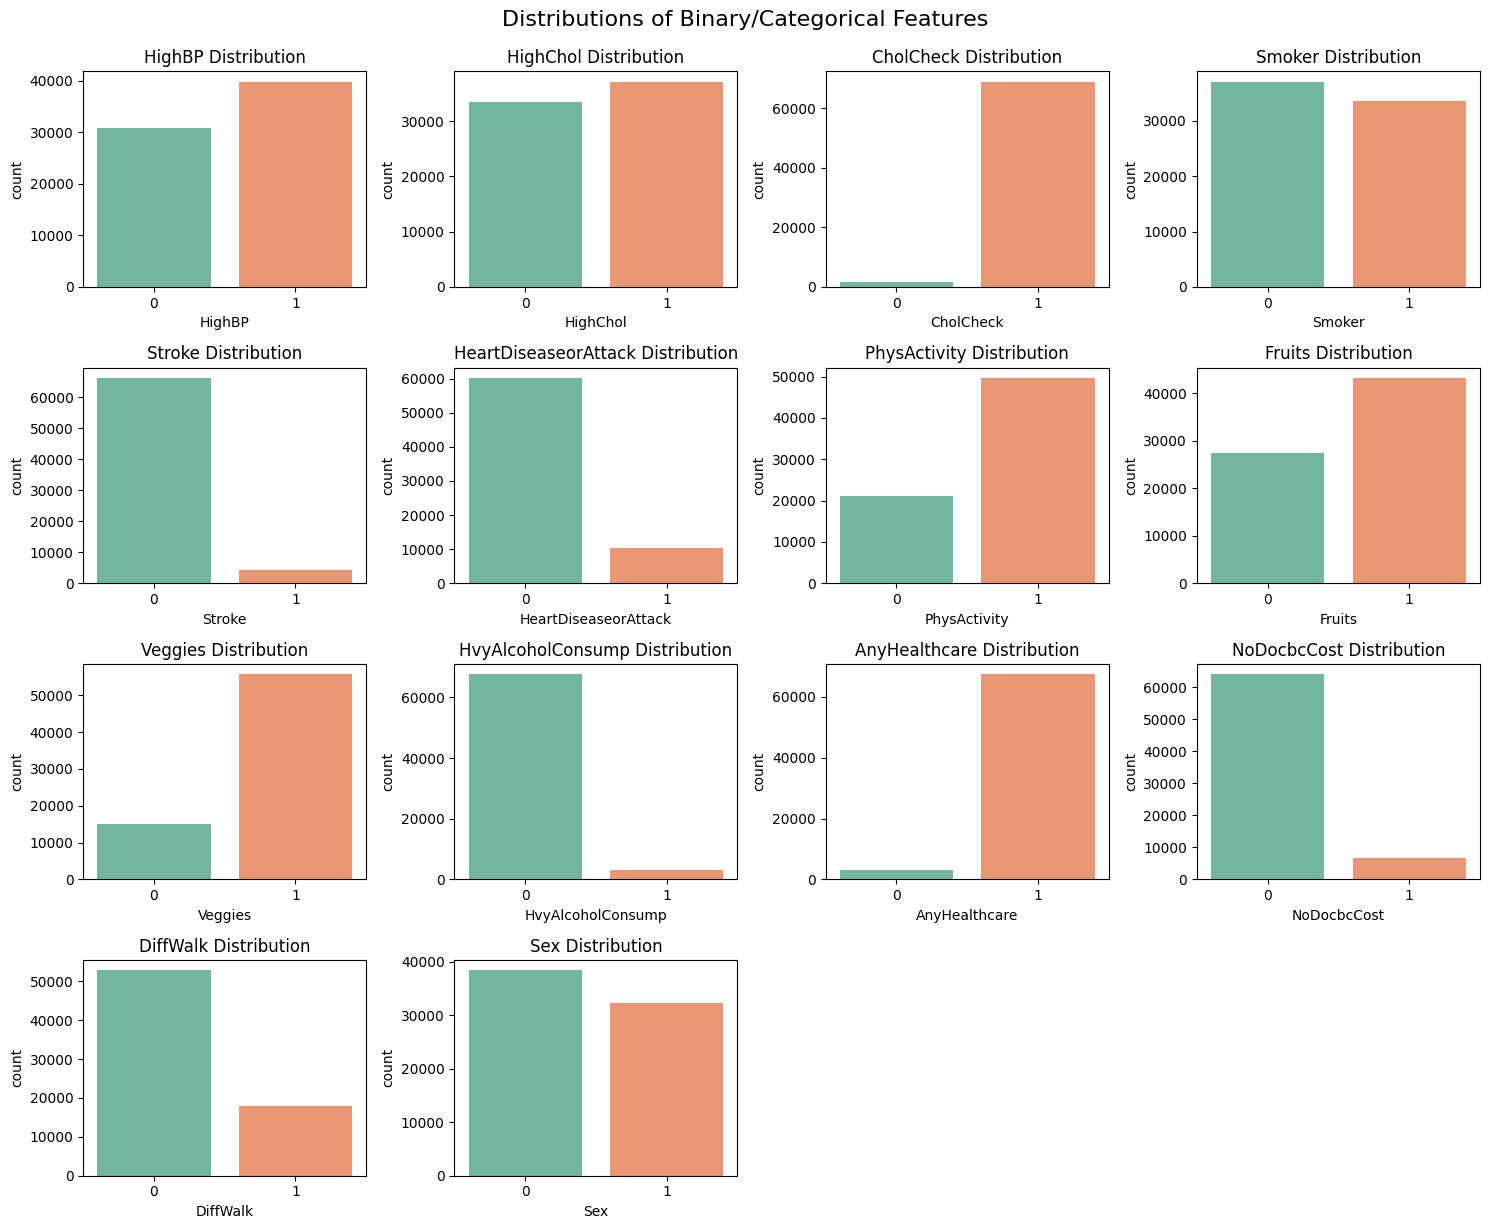

In [32]:
# Plot binary/categorical feature distributions
binary_cols = [col for col in diabetes_df.columns if diabetes_df[col].nunique() == 2 and col != 'Diabetes_binary']

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    sns.countplot(data=diabetes_df, x=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} Distribution")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Distributions of Binary/Categorical Features", y=1.02, fontsize=16)
plt.show()

This plot is about features with binary values and how likely each group is to have diabetes.

Key takeaways:
1. Attributes such as `HighBP`, `CholCheck`, `Stroke`, and `DiffWalk` exhibit very high presence of diabetes for `1` as against `0`.
2. For instance, individuals who can't walk (`DiffWalk=1`) have **twice the occurrence of diabetes** as those who can.
3. Such binary flags are good candidates for risk factors and also for encoding comorbidities.

####3.Correlation matrix and heatmap

/tmp/ipython-input-33-1019710279.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette="viridis")


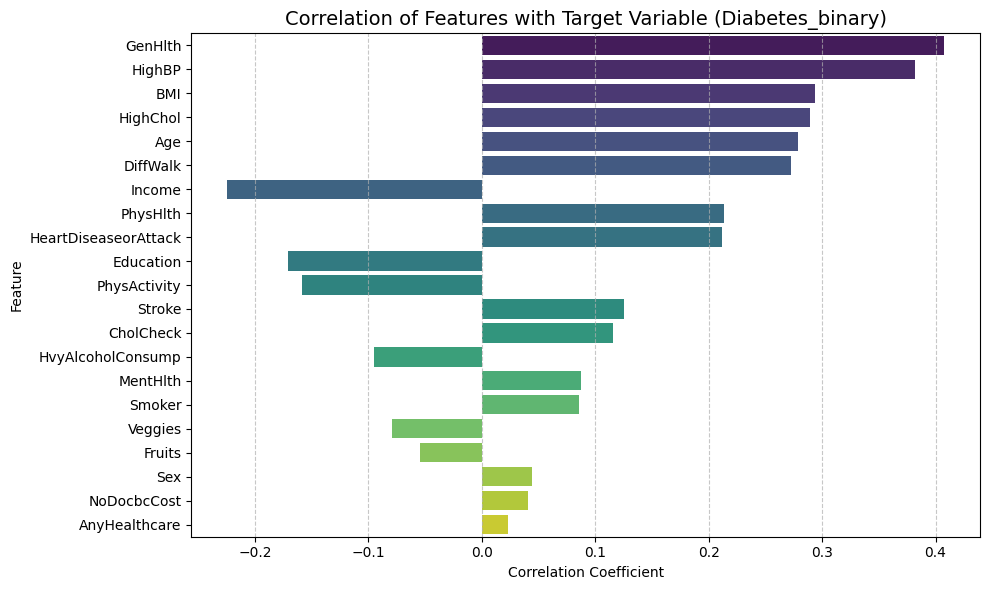

In [33]:
correlations = diabetes_df.corr()['Diabetes_binary'].drop('Diabetes_binary').sort_values(key=abs, ascending=False)

# Bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette="viridis")
plt.title("Correlation of Features with Target Variable (Diabetes_binary)", fontsize=14)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Key Takeaways:**
1. The highest ~6 features have high linear correlation with the diabetes label and are first choice model input candidates.
2. Low linear correlation features, on the other hand, can be very important in **non-linear models** (e.g., Random Forests, Gradient Boosting).
3. This narrative also affects **feature prioritization** and potential **dimensionality reduction** techniques in future modeling stages.

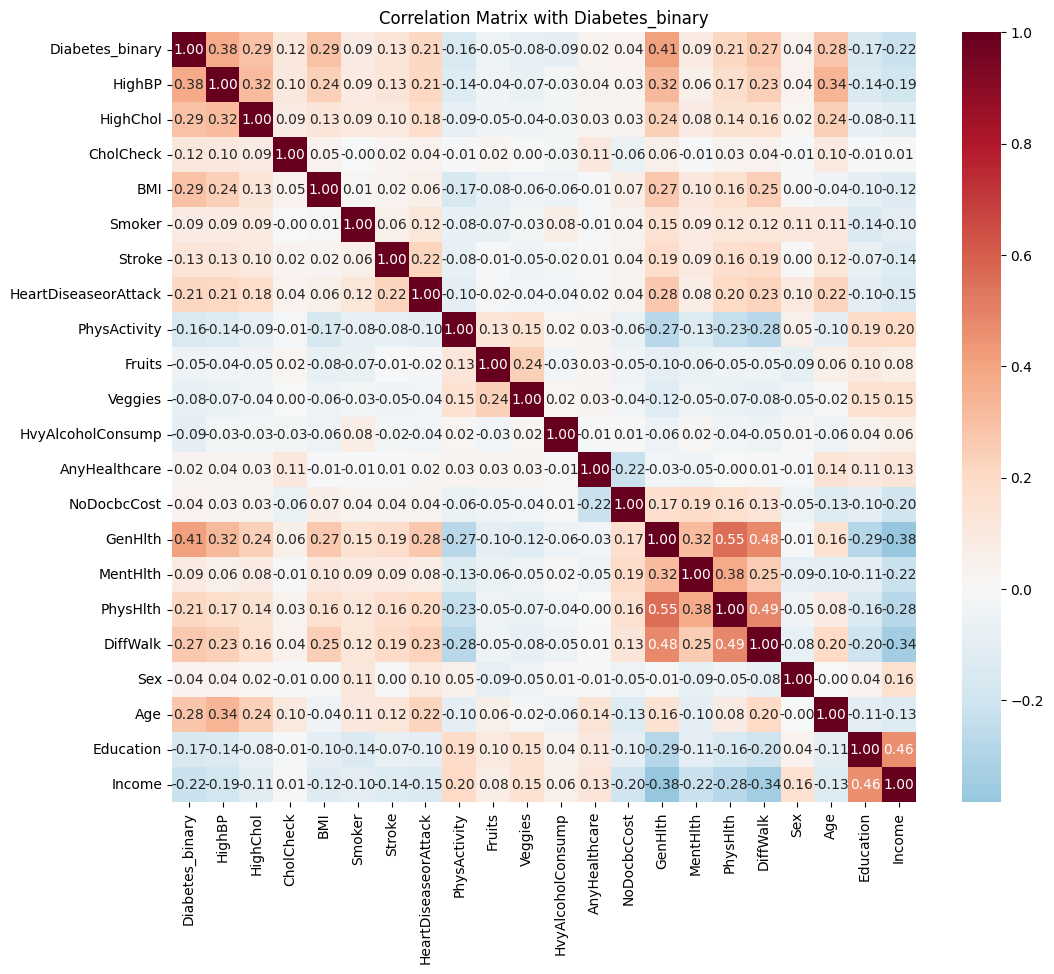

In [34]:
# Compute correlation matrix
plt.figure(figsize=(12, 10))
corr = diabetes_df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title("Correlation Matrix with Diabetes_binary")
plt.show()

A correlation heatmap which shows correlation of each numeric feature and the target variable.

Key Findings:
1. DiffWalk, PhysHlth, HighBP, and GenHlth are features most correlated to label for diabetes
2. There is no problematic multicollinearity and there are mostly moderate correlations, which can accommodate independent contribution upon model building.

####4.Point Plot of General Health vs Diabetic risk

/tmp/ipython-input-35-605744757.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(data=diabetes_df, x="GenHlth", y="Diabetes_binary", ci=None, color='blue')


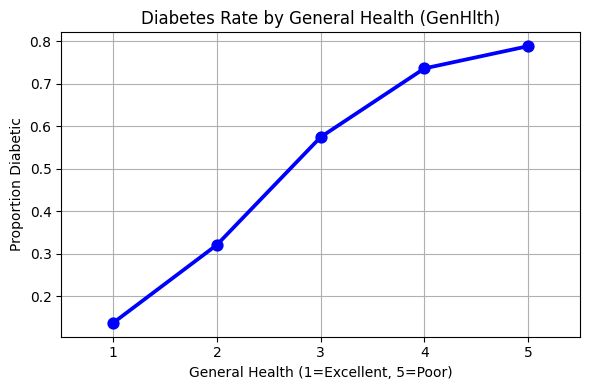

In [35]:
# GenHlth: 1 (Excellent) to 5 (Poor)
plt.figure(figsize=(6, 4))
sns.pointplot(data=diabetes_df, x="GenHlth", y="Diabetes_binary", ci=None, color='blue')
plt.title("Diabetes Rate by General Health (GenHlth)")
plt.ylabel("Proportion Diabetic")
plt.xlabel("General Health (1=Excellent, 5=Poor)")
plt.grid(True)
plt.tight_layout()
plt.show()


A point plot which shows an relationship of risk of diabetes with worsening health.

Key findings:

1. Clear upward trend : As `GenHlth` decreases from 1 (Excellent) to 5 (Poor), there is growing prevalence of diabetes.
2. This is what strengthens the predictive capacity of self-rated health condition.

####5.Pairplots of Top Correlated Features

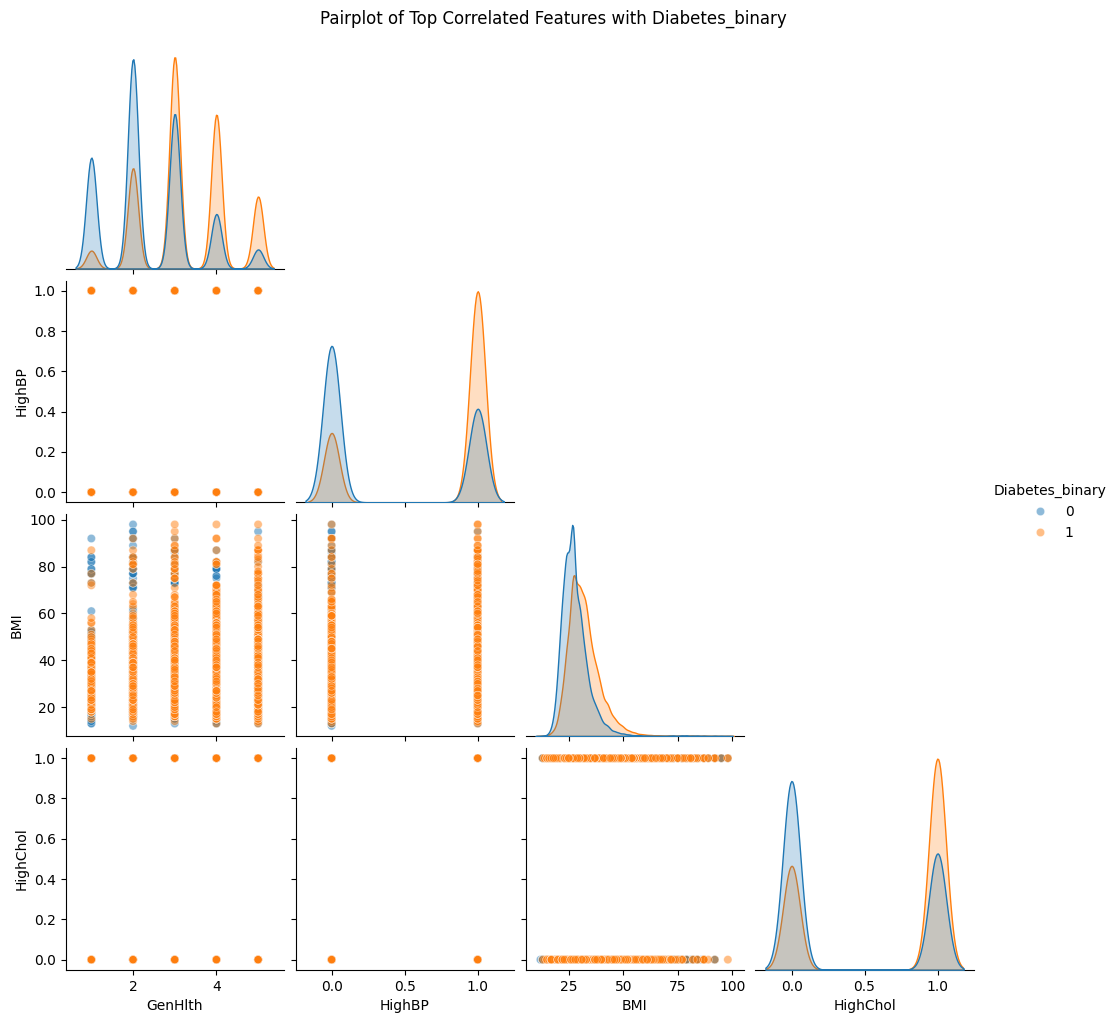

In [36]:
# Select top correlated features with target
top_corr = diabetes_df.corr()['Diabetes_binary'].abs().sort_values(ascending=False)[1:5].index.tolist()

sns.pairplot(diabetes_df, vars=top_corr, hue="Diabetes_binary", plot_kws={'alpha':0.5}, corner=True)
plt.suptitle("Pairplot of Top Correlated Features with Diabetes_binary", y=1.02)
plt.show()

This plot shows the multivariate interactions and clustering tendencies among key features.

Key findings:
1. It identifies significant clustering and change of distribution between diabetic and non-diabetic sets for variables `BMI`, `GenHlth`, and `PhysHlth`.
2. This would suggest that **tree-based classifiers** or other classifiers of non-linear nature that can accommodate interactions between features could hold promise.

####Summary of EDA Insights

After conducting thorough exploratory data analysis (EDA), several important insights were gathered regarding the structure, quality, and predictive potential of the dataset:

**Dataset Composition**
1. The original dataset consists of 70692 entries and 22 features including a binary target variable (`Diabetes_binary`) that indicates the presence of diabetes.
2. The target class is perfectly balanced(50/50) which is ideal for training of classification models.

**Data Quality check and cleaning**
1. No null or missing values.
2. 1635 rows were observed to be duplicated and were dropped as it was just 2.31% of original dataset and its removal was not causing any changes in descriptive stats.
3. The balance of target class also changed by just 0.82% and so no corrective action was required since there is an impact of model fairness is unlikely.

**Feature Characteristics**
The feature variables include a mix of:
 1. Continuous : BMI, PhysHlth, MentHlth.
 2. Ordinal : `GenHlth` (1 = Excellent to 5 = Poor), `Age` (binned age groups)
 3. Binary indicators: HighBP, HighChol, CholCheck, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, AnyHealthcare, Fruits, Veggies, HvyAlcoholConsump, NoDocbcCost, DiffWalk and Sex.
 4. All features are numerical which allows direct compatibility with most ML models without encoding.


Some Important Relationships with Target variable(Diabetes_binary)

Strong Positive Correlation with diabetes: GenHlth, DiffWalk, HighBP, BMI & PhysHlth. These features showed clear separation between diabetic and non-diabetic groups across the plots.
Weak or no linear correlations observed for Education, Income and AnyHealthcare which will be useful in non-linear models.

**Visual Insights:**

Bar and boxplot charts showed that key features had clear distribution shifts across the diabetes classes.
With decreasing self-rating of health points, the plot showed an increase in diabetes risk.
Correlation heatmap validated moderate correlation between features and no critical mult-collinearity issues.
Correlation bar plot provided ranking of feature importance according to their respective linear association with the target.



---

# Task 2: Data Preparation and Modeling

Now we will proceed with the data splitting and prepration for model training.

##2.1 Data Splitting

We will split the datasetin to 3 parts using the 70-15-15 split
1. Training Set (70%) - To train the model
2. Validation Set (15%) - To perform hyperparamter tuning and model selection.
3. Test Set (15%) - To be used for final performance evaluation only.

##Reasons for using this split
1. Since this is a huge dataset containing approximately 70000 rows, there is plenty of data for model learning, stable tuning and is large enough to assess generalization.
2. More training examples will lead to better decision boundaries for models llike Logistic Regression, KNN and SVM.
3. With equal-sized validation and test set, comparision across models will be fair. This will also simplify cross-validation if it needs to be done.
4. With this split, we can perform ample validation and robust final testing without decreasing training power.

---

In [37]:
#Loading the cleaned dataset
diabetes_clean = pd.read_csv("diabetes_clean_bmi_capped.csv")

In [38]:
#Checking the dataset to ensure that all columns are present
diabetes_clean.shape
diabetes_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69057 entries, 0 to 69056
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Diabetes_binary       69057 non-null  int64
 1   HighBP                69057 non-null  int64
 2   HighChol              69057 non-null  int64
 3   CholCheck             69057 non-null  int64
 4   Smoker                69057 non-null  int64
 5   Stroke                69057 non-null  int64
 6   HeartDiseaseorAttack  69057 non-null  int64
 7   PhysActivity          69057 non-null  int64
 8   Fruits                69057 non-null  int64
 9   Veggies               69057 non-null  int64
 10  HvyAlcoholConsump     69057 non-null  int64
 11  AnyHealthcare         69057 non-null  int64
 12  NoDocbcCost           69057 non-null  int64
 13  GenHlth               69057 non-null  int64
 14  MentHlth              69057 non-null  int64
 15  PhysHlth              69057 non-null  int64
 16  Diff

In [39]:
#Splitting the variable features and target variable into x and y respectively.
X = diabetes_clean.drop(columns=['Diabetes_binary'])
y = diabetes_clean['Diabetes_binary']

In the above codeblock we are splitting the dataframe into two variables. x contains the features while y contains the target variable.

This seperation is necessary before performing model training as most ML algorithms require input features and target variables to be passed seperately.

In [40]:
# Step 1 :  creating the test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42
)

# Step 2 : Split the remaining 85% into 70% train and 15% val
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42
)


# Confirming the split proportions
print("Train set:", X_train.shape, f"{round(len(X_train)/len(X)*100, 2)}%")
print("Validation set:", X_val.shape, f"{round(len(X_val)/len(X)*100, 2)}%")
print("Test set:", X_test.shape, f"{round(len(X_test)/len(X)*100, 2)}%")


Train set: (48337, 21) 70.0%
Validation set: (10361, 21) 15.0%
Test set: (10359, 21) 15.0%


We have split the cleaned dataset into 3 parts: Trainset-> 70%,Validation set-> 15%, Test set-> 15%.

we also confirmed the data has been split correctly.

In [41]:
#Saving the split data

# Save training data
pd.DataFrame(X_train).to_csv("X_train.csv", index=False)
pd.Series(y_train).to_csv("y_train.csv", index=False)

# Save validation data
pd.DataFrame(X_val).to_csv("X_val.csv", index=False)
pd.Series(y_val).to_csv("y_val.csv", index=False)

# Save test data
pd.DataFrame(X_test).to_csv("X_test.csv", index=False)
pd.Series(y_test).to_csv("y_test.csv", index=False)

Now we will proceed with feature scaling using RobustScaler

In [42]:
#Initializing the scaler
scaler =RobustScaler()

#Fitting all the training data and transforming all the splits

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

RobustScaler is used here in feature scaling due to the following reasons:
1. Even though we performed the IQR capping, there are chances of residual outliers and mminor skewness.
2. It will balnce resistance to outliers(even after capping)
3. Mixed feature types will have scaling
4. We are using scale-senstive models(Logistic Regression, SVM, KNN)

In [43]:
# Retaining column names for interpretability:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


In the above codeblock, we are converting scaled arrays back to DataFrames to  enhanced model readablity & output readability.It is also useful debugging and maintainability.
Maintains pipeline consistency where Dataframes keeps things consistent and easier to understand.

**Now we will proceed with Model Training**

##2.2 Model training

####Model 1: Logistic Regression

According to my dataset, i chose Logistic Regression due to it's simplicity,interpretability and its effectiveness in binary classification problems. Due to numerical heavy nature of the data and having an almost balanced target class, Logistic Regression was the ideal choice and a strong starting point.

In [44]:
# Initializing and training the model
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_scaled_df, y_train)

# Predict on validation data
y_val_pred = logreg_model.predict(X_val_scaled_df)
y_val_proba = logreg_model.predict_proba(X_val_scaled_df)[:, 1]  # probabilities for ROC AUC


#### Model 2: KNN(K-Nearest Neighbours)

This model is being used because the dataset is moderate sized, balanced classes and features robustly scaled. This model does not make assumptions about the data distribution and effectively captures local patterns in the data.

Training the model

In [45]:
#Importing required libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

In [46]:
#Initializing and training the model
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune this later
knn_model.fit(X_train_scaled_df, y_train)

KNeighborsClassifier()

in above block we initialize and train the model. We have chosen the n_neighbors = 5. Which means that for any data point, the model will look for the 5 closes samples and assigns the class that those 5 neighbors belong to. We have strated with value 5 since it works well for moderately sized, clean and scaled datasets. This will avoid majority class bias.

### Model 3: Support Vector Machine(SVM)

This model was chosen due to the scaled features of the not too large dataset, where SVM can perform effectively and capture non-linear decision boundaries. It is well suited for binary classification tasks tha contain high dimensional feature spaces like this dataset.

Training the model

In [47]:
#Initializing the model with probability outputs enabled
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

#Fitting the training data
svm_model.fit(X_train_scaled_df, y_train)

SVC(probability=True, random_state=42)

Here we have use SVC kernel as 'rbf' to help the model in identification of non-linear patterns in the data.
prbability is set to True as we will compute ROC AUC scores later.
We used the preprocessed and scaled data.

### Model 4: Random Forest Classifier

Training the model

In [48]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

#Training model on Data set
rf_model.fit(X_train_scaled_df, y_train)


RandomForestClassifier(random_state=42)

In the above code , we have used 100 decision trees and aggregrated them.
random_state = 42 ensures result producibility. We have fit the Random Forest on scaled training dataset(X_train_scaled_df).

### Model 5: Gradient Boosting Model

This model is a powerful ensemble learning technique which builds models sequentially bey focusing on errors of previous models. It is well suited for our numerical heavy structure dataset. This model has high predictive accuracy in classification tasks, good handling of non-linear relationships of target and features, captures multiple feature interactions and their importance.

Training the model

In [116]:
# Initialize Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model
gb_model.fit(X_train_scaled_df, y_train)

GradientBoostingClassifier(random_state=42)

We are training with a 100 trees(default value), learning_rate of 0.1 and max depth of 3 since it provides a good balance between performance and training. It will prevent overfitting, efficiently trains and robustly handles data and their feature interactions.

##2.3 To check whether the models are trained

In [50]:
# Dictionary of models
models = {
    "Logistic Regression": logreg_model,
    "KNN": knn_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

print("🔍 Sanity Checks for Trained Models\n")

for name, model in models.items():
    print(f"🚀 Checking: {name}")
    print("-" * 40)

    try:
        # Check 1: Training and Validation Accuracy
        train_acc = model.score(X_train_scaled_df, y_train)
        val_acc = model.score(X_val_scaled_df, y_val)
        print(f"✅ Training Accuracy: {train_acc:.4f}")
        print(f"✅ Validation Accuracy: {val_acc:.4f}")

        # Check 2: Sample Predictions
        sample_preds = model.predict(X_val_scaled_df[:5])
        print("✅ Sample Predictions:", sample_preds)

        # Check 3: Class distribution in predictions
        full_preds = model.predict(X_val_scaled_df)

        # Use pandas value_counts as a robust workaround
        class_distribution = pd.Series(full_preds).value_counts().to_dict()
        print("✅ Class Distribution in Validation Predictions:", class_distribution)


        # Check 4: Prediction Probabilities (if supported)
        if hasattr(model, "predict_proba"):
            proba_sample = model.predict_proba(X_val_scaled_df[:5])
            print("✅ Sample Prediction Probabilities:\n", proba_sample)
            assert np.all((proba_sample >= 0) & (proba_sample <= 1)), "❌ Probabilities out of range!"

    except NotFittedError as e:
        print(f"❌ Model not fitted: {e}")
    except Exception as ex:
        print(f"⚠️ Error detected: {ex}")

    print("=" * 60 + "\n")

🔍 Sanity Checks for Trained Models

🚀 Checking: Logistic Regression
----------------------------------------
✅ Training Accuracy: 0.7438
✅ Validation Accuracy: 0.7521
✅ Sample Predictions: [0 0 1 1 0]
✅ Class Distribution in Validation Predictions: {1: 5533, 0: 4828}
✅ Sample Prediction Probabilities:
 [[0.56149753 0.43850247]
 [0.63103994 0.36896006]
 [0.07289363 0.92710637]
 [0.09681885 0.90318115]
 [0.78588947 0.21411053]]

🚀 Checking: KNN
----------------------------------------
✅ Training Accuracy: 0.7965
✅ Validation Accuracy: 0.7099
✅ Sample Predictions: [0 1 1 1 0]
✅ Class Distribution in Validation Predictions: {1: 5646, 0: 4715}
✅ Sample Prediction Probabilities:
 [[0.8 0.2]
 [0.4 0.6]
 [0.4 0.6]
 [0.  1. ]
 [0.8 0.2]]

🚀 Checking: SVM
----------------------------------------
✅ Training Accuracy: 0.7528
✅ Validation Accuracy: 0.7567
✅ Sample Predictions: [0 0 1 1 0]
✅ Class Distribution in Validation Predictions: {1: 6015, 0: 4346}
✅ Sample Prediction Probabilities:
 [[0.5826

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


The above outputs tells us that the models have been trained and are working fine.

1. Logistic Regression: Good Generalization, balanced and calibrated predictions
2. KNN : Overfitting observed due to lower validation accuracy, possible skewness to class 0.
3. SVM : Excellent Generalization, balanced prediction split and smooth probabilities and well distributed.
4. Random Forest: Extreme overfitting due to significant difference in training and validation accuracy, reasonable prediction balance.
5. Gradient Boost: Excellent Generalization, most balanced predictions  and refined decision boundaries as noticed from the probabilities scores.

#Task 3: Evaluation

Now we will evaluate every model seperately, perform error analysis and improve them following which the model will be retrained and compared to the performance of the previous untuned trained model.

A function has been defined to get the required metrics for model evaluation and use the same function across different models for both orignal model and tuned model

In [51]:
# Defining evaluation function of model for each class of traget variable
def evaluate_model(model, X_train, y_train, X_val, y_val):
    metrics = []

    def compute_metrics(X, y_true):
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)

        return {
            'Precision (Class 0)': precision_score(y_true, y_pred, pos_label=0),
            'Precision (Class 1)': precision_score(y_true, y_pred, pos_label=1),
            'Recall (Class 0)': recall_score(y_true, y_pred, pos_label=0),
            'Recall (Class 1)': recall_score(y_true, y_pred, pos_label=1),
            'F1 Score (Class 0)': f1_score(y_true, y_pred, pos_label=0),
            'F1 Score (Class 1)': f1_score(y_true, y_pred, pos_label=1),
            'ROC AUC (Class 0)': roc_auc_score(y_true, y_prob[:, 0]),
            'ROC AUC (Class 1)': roc_auc_score(y_true, y_prob[:, 1]),
            'Accuracy': accuracy_score(y_true, y_pred)
        }

    train_metrics = compute_metrics(X_train, y_train)
    val_metrics = compute_metrics(X_val, y_val)

    # Format into DataFrame
    rows = []
    for metric in train_metrics.keys():
        rows.append([
            metric,
            round(train_metrics[metric], 3),
            round(val_metrics[metric], 3)
        ])

    return pd.DataFrame(rows, columns=["Metric", "Train", "Validation"])


###3.1. Logistic Regression Model Evaluation

####3.1.1 Comparision of model performance on based on training data vs validation data

In [52]:
#Training Data vs Validation data
evaluate_model(logreg_model, X_train_scaled_df, y_train, X_val_scaled_df, y_val)


,Metric,Train,Validation
0,Precision (Class 0),0.751,0.762
1,Precision (Class 1),0.738,0.744
2,Recall (Class 0),0.717,0.722
3,Recall (Class 1),0.770,0.781
4,F1 Score (Class 0),0.734,0.741
5,F1 Score (Class 1),0.753,0.762
6,ROC AUC (Class 0),0.180,0.171
7,ROC AUC (Class 1),0.820,0.829
8,Accuracy,0.744,0.752


Generalization: The model is generalizing well, as proved by its consistent performance on both the training and validation sets.

Fitting:

The model is neither underfitting nor overfitting. It performs slightly better on the validation set than on the training set, indicating effective learning without memorizing the training data.

Evaluation Metrics:

Precision, recall, and F1-Score for Class 1 (diabetic prediction) are balanced and slightly better on the validation set, which is desirable for identifying diabetics without sacrificing the identification of non-diabetics.

ROC-AUC for Class 1 is high, confirming the model's ability to distinguish between diabetic and non-diabetic patients.

Overall, the model is performing well with good generalization and is not showing signs of underfitting or overfitting.

In [53]:
# Predict on validation data
y_val_pred = logreg_model.predict(X_val_scaled_df)
y_val_proba = logreg_model.predict_proba(X_val_scaled_df)[:, 1]  # probabilities for ROC AUC

# Step 3: Evaluate model performance
print("📋 Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred))

print("🎯 ROC AUC Score:", roc_auc_score(y_val, y_val_proba))


📋 Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.76      0.72      0.74      5095
           1       0.74      0.78      0.76      5266

    accuracy                           0.75     10361
   macro avg       0.75      0.75      0.75     10361
weighted avg       0.75      0.75      0.75     10361

🎯 ROC AUC Score: 0.8291049437817808


By using classification report we recieve a summary of key evalutaion metrics for the model.
1. It shows a balanced performace for both classes and identifies diabetic cases well.
2. A high ROC AUC score of 0.83 indicates the good ability to distinguish between two classes.
3. The model maintains consistency accross precision, recall and F1-score which makes it a storng baseline for comparision.
4. The model performs reliably and predictably while handling the data complexity.

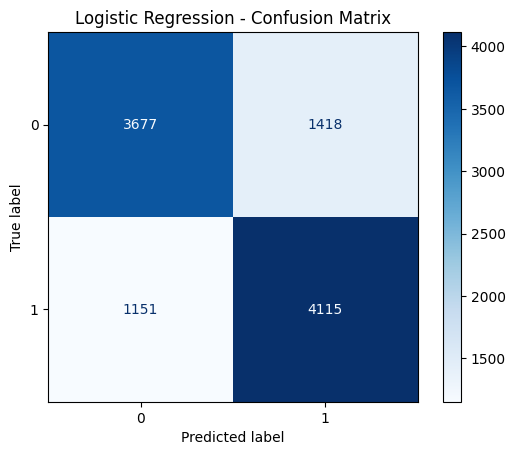

In [54]:
# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

Confusion Matrix gives us detailed insights of our model performance on each class. What the matrix tells us:

1. True Positives(4115): Model correctly predicts diabetic cases which indicates good recall.
2. True Negatives(3677): Correct identification of non-diabetic cases.
3. False Positives(1418): Incorrect flagging of diabetic cases which may cause unneccessary checkups, but in health-care it is often better to err on the side of caution.
4. False Negatives(1151): Diabetic cases missed by the model. This is moderate and reflects a reall of 0.78 which is acceptable.

####3.1.2 Logistic Regression: Qualitative Error Analysis

In [55]:
# Get predicted classes and probabilities
y_val_pred = logreg_model.predict(X_val_scaled_df)
y_val_probs = logreg_model.predict_proba(X_val_scaled_df)[:, 1]

# Mask for false positives and false negatives
false_positives = (y_val_pred == 1) & (y_val == 0)
false_negatives = (y_val_pred == 0) & (y_val == 1)

# Combine with input features for review
fp_samples = X_val_scaled_df[false_positives].copy()
fp_samples['True Label'] = y_val[false_positives].values
fp_samples['Predicted Label'] = y_val_pred[false_positives]
fp_samples['Predicted Prob'] = y_val_probs[false_positives]

fn_samples = X_val_scaled_df[false_negatives].copy()
fn_samples['True Label'] = y_val[false_negatives].values
fn_samples['Predicted Label'] = y_val_pred[false_negatives]
fn_samples['Predicted Prob'] = y_val_probs[false_negatives]

# Show a few false positives and false negatives
fp_samples.head(), fn_samples.head()


(       HighBP  HighChol  CholCheck  Smoker  Stroke  HeartDiseaseorAttack  \
 13304     0.0       0.0        0.0     0.0     0.0                   0.0   
 4224     -1.0      -1.0        0.0     0.0     0.0                   0.0   
 33029     0.0       0.0        0.0     1.0     0.0                   1.0   
 31832     0.0      -1.0        0.0     1.0     0.0                   0.0   
 3991     -1.0      -1.0        0.0     1.0     0.0                   1.0   
 
        PhysActivity  Fruits  Veggies  HvyAlcoholConsump  ...  PhysHlth  \
 13304           0.0    -1.0      0.0                0.0  ...  0.000000   
 4224            0.0     0.0     -1.0                0.0  ...  5.000000   
 33029           0.0    -1.0      0.0                1.0  ...  0.000000   
 31832          -1.0    -1.0     -1.0                0.0  ...  0.000000   
 3991           -1.0     0.0     -1.0                0.0  ...  1.666667   
 
        DiffWalk  Sex   Age  Education  Income  BMI_capped  True Label  \
 13304    

Key Takeaways:
- Logistic Regression is sensitive to the presence of missing-like values (`-1.0`), which may affect learning.
- The model seems to respond to **clear-cut features**, but fails when input combinations are **ambiguous or contradictory**.
- This motivates:
  - Handling/imputing `-1.0` values more carefully
  - Adding interaction features or switching to models that can capture non-linear combinations (e.g., Random Forests)
  - Tuning the decision threshold (e.g., use 0.45 instead of 0.5 for higher recall)


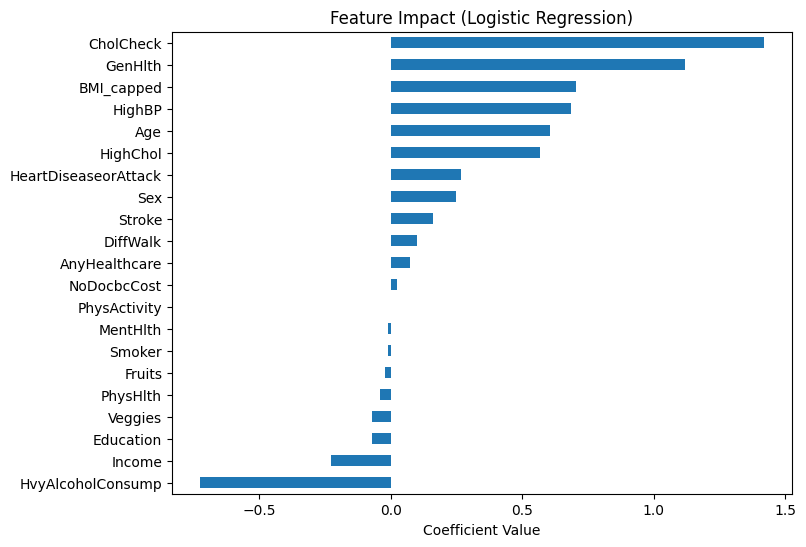

In [56]:
# Create a feature-importance plot from coefficients
coefficients = pd.Series(logreg_model.coef_[0], index=X_train_scaled_df.columns)
coefficients.sort_values().plot(kind='barh', figsize=(8, 6), title="Feature Impact (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.show()

Some important features according to the plot:
1. GenHlth(General Health), BMI_capped(BMI values)& High BP tells us that poor health conditions in general increases risk of diabetes.
2. Features like fruits, Veggies and Physical Activity lowers risk of diabetes.

####3.1.3 Model Improvement by using class_weight='unbalanced' and retraining

In [57]:
# Train logistic regression with balanced class weights
logreg_balanced = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    random_state=42
)

# Fit on scaled training data
logreg_balanced.fit(X_train_scaled_df, y_train)

# Evaluate side-by-side
evaluation_df = evaluate_model(
    logreg_balanced,
    X_train_scaled_df,
    y_train,
    X_val_scaled_df,
    y_val
)

# Apply float formatting only to numeric columns
numeric_cols = evaluation_df.select_dtypes(include=np.number).columns
evaluation_df.style.format({col: "{:.4f}" for col in numeric_cols})

,Metric,Train,Validation
0,Precision (Class 0),0.7460,0.7570
1,Precision (Class 1),0.7410,0.7460
2,Recall (Class 0),0.7250,0.7280
3,Recall (Class 1),0.7610,0.7740
4,F1 Score (Class 0),0.7350,0.7420
5,F1 Score (Class 1),0.7510,0.7600
6,ROC AUC (Class 0),0.1800,0.1710
7,ROC AUC (Class 1),0.8200,0.8290
8,Accuracy,0.7430,0.7510


Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.76      0.73      0.74      5095
           1       0.75      0.77      0.76      5266

    accuracy                           0.75     10361
   macro avg       0.75      0.75      0.75     10361
weighted avg       0.75      0.75      0.75     10361

ROC AUC (Validation): 0.8290996139807761


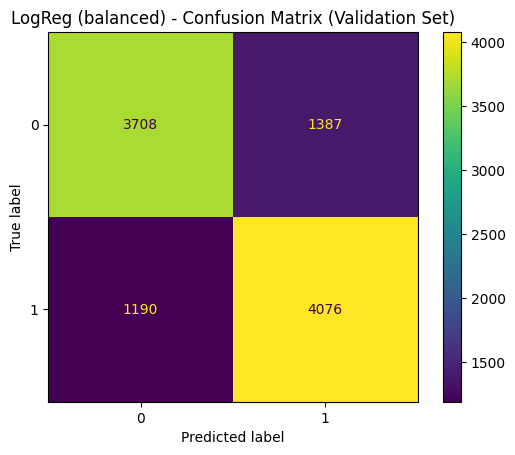

In [58]:
#Model performance after tuning
y_val_pred_bal = logreg_balanced.predict(X_val_scaled_df)
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_bal))

y_val_probs_bal = logreg_balanced.predict_proba(X_val_scaled_df)[:, 1]
print("ROC AUC (Validation):", roc_auc_score(y_val, y_val_probs_bal))

ConfusionMatrixDisplay.from_estimator(
    logreg_balanced,
    X_val_scaled_df, y_val
)
plt.title("LogReg (balanced) - Confusion Matrix (Validation Set)")
plt.show()



####3.1.4 Final Evaluation Summary

The class_weight='balanced' adjusted Logistic Regression model did not perform better than the untuned initial model. It decreased false positives (from 1418 to 1387) but increased false negatives (from 1151 to 1190), which is the more critical issue if class 1 is a high-risk class. Recall for class 1 falls from 0.78 to 0.77, and overall ROC AUC remained unchanged at ~0.829 because the tuned model loses recall (sensitivity) but not discrimination or accuracy, the original model is better objectively in this case, especially if one's aim is to cut down on false negatives.

###3.2 KNN Model Model Evaluation

####3.2.1 Comparision of model performance based on training data vs validation data

In [99]:
#Training data vs Evaluation Data
evaluate_model(knn_model, X_train_scaled_df, y_train, X_val_scaled_df, y_val)

,Metric,Train,Validation
0,Precision (Class 0),0.811,0.722
1,Precision (Class 1),0.784,0.700
2,Recall (Class 0),0.765,0.668
3,Recall (Class 1),0.827,0.751
4,F1 Score (Class 0),0.787,0.694
5,F1 Score (Class 1),0.805,0.725
6,ROC AUC (Class 0),0.119,0.234
7,ROC AUC (Class 1),0.881,0.766
8,Accuracy,0.797,0.710


There is a clear performance drop from training to validation across all major metrics. This gap suggests that the KNN model is likely overfitting to the training data and does not generalize as well to unseen examples.

In [60]:
#Making predictions on validation set
val_pred_knn = knn_model.predict(X_val_scaled_df)
val_prob_knn = knn_model.predict_proba(X_val_scaled_df)[:,1]

val_pred_knn -> Predicts the class labels val_prod_knn -> Predicts class probabilities to calculate ROC AUC score.

In [61]:
#Classification report and ROC AUC score (VAlidation Set)
print(" Classification Report (Validation Set - KNN):")
print(classification_report(y_val, val_pred_knn))

print(" ROC AUC Score: ", roc_auc_score(y_val, val_prob_knn))

 Classification Report (Validation Set - KNN):
              precision    recall  f1-score   support

           0       0.72      0.67      0.69      5095
           1       0.70      0.75      0.72      5266

    accuracy                           0.71     10361
   macro avg       0.71      0.71      0.71     10361
weighted avg       0.71      0.71      0.71     10361

 ROC AUC Score:  0.7660495216783134


We received a summary of key evaluation metrics by using classification report below:
1. Recall for class 1(diabetic) is quite high(0.75) which means the model can identify positive cases fairly well. It struggled to identify non-diabetic cases(class 0) which can also lead to some indiviuals flasely flagged
2. The model twas able to make 70% of correct guess on diabetic cases.
3. F1-score(0.72): This suggests that the model has a balanced approach being neither too conservative or aggressive when predicitng positive cases.

Overall accuracy is 71% and ROC AUC of 0.77, suggesting the model's adequate seperatio capability but not confident across all thresholds.

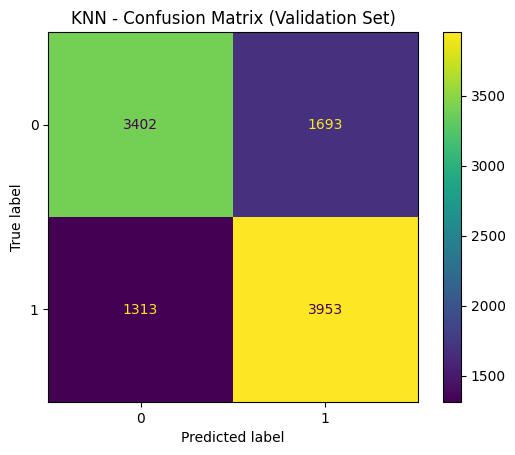

In [62]:
ConfusionMatrixDisplay.from_estimator(knn_model, X_val_scaled_df, y_val)
plt.title("KNN - Confusion Matrix (Validation Set)")
plt.show()


From the confusion matrix we observed the following details:

1. True Positives(3953): These many diabetic cases were correctly identified which suggests decent recall.
2. True Negatives(3401): Model accurately identified non-diabetic cases.
3. False Positives(1693): Wrong flagging of individual as diabetic, yet accepted in healthcare to avoid missing true cases.
4. False Negatives(1313): Model missed indivuals who are actually be diabetic suggesting a compartatively weak recall to the diabetic-positve cases.


This indicates that the model correctly identifies the majority of both class 0 and class 1 samples, but there are still notable errors in both directions — particularly a high number of false positives.

####3.2.2 Qualitative Error Analysis

In [63]:
# Fit NearestNeighbors model on validation set
nn_model = NearestNeighbors(n_neighbors=5)
nn_model.fit(X_val_scaled_df)

# Get predicted classes and probabilities for KNN
val_pred_knn = knn_model.predict(X_val_scaled_df)
val_prob_knn = knn_model.predict_proba(X_val_scaled_df)[:, 1]

# Mask for false negatives for KNN
false_negatives_knn = (val_pred_knn == 0) & (y_val == 1)

# Combine with input features for review
fn_samples_knn = X_val_scaled_df[false_negatives_knn].copy()
fn_samples_knn['True Label'] = y_val[false_negatives_knn].values
fn_samples_knn['Predicted Label'] = val_pred_knn[false_negatives_knn]
fn_samples_knn['Predicted Prob'] = val_prob_knn[false_negatives_knn]

# Example: take one false negative index
sample_idx = fn_samples_knn.index[0]  # Index of a misclassified sample

# Get its 5 nearest neighbors in the validation set
distances, indices = nn_model.kneighbors([X_val_scaled_df.loc[sample_idx]])

# Display result
print(f"Misclassified sample index: {sample_idx}")
print("Distances to Neighbors:", distances[0])
print("Neighbor Indices:", indices[0])
print("Neighbor True Labels:", y_val.reset_index(drop=True).iloc[indices[0]].values)

Misclassified sample index: 59971
Distances to Neighbors: [0.         0.92796073 0.97271813 1.00086768 1.06147827]
Neighbor Indices: [  24 4192 2036 4754 5121]
Neighbor True Labels: [1 0 0 1 0]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


Misclassified Sample Analysis – KNN

- **Index:** 59971  
- **True Label:** 1 | **Predicted:** 0 (**False Negative**)  
- **Nearest Neighbors' Labels:** [1, 0, 0, 1, 0]  
- **Majority Vote:** 3 out of 5 neighbors were class 0

Despite having two correct class 1 neighbors (including an exact match), KNN predicted class 0 due to majority voting. The small distance differences suggest the sample lies in a **blurred class boundary**, highlighting KNN's vulnerability in **locally mixed regions**.


####3.2.3 Model Improvement using Distance-Weighted Voting (weights='distance')

In [64]:


# Distance-weighted KNN
knn_weighted = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_weighted.fit(X_train_scaled_df, y_train)

# Evaluate side-by-side
evaluation_df = evaluate_model(
    logreg_balanced,
   X_train_scaled_df,
   y_train,
   X_val_scaled_df,
    y_val
)
# Apply float formatting only to numeric columns
numeric_cols = evaluation_df.select_dtypes(include=np.number).columns
evaluation_df.style.format({col: "{:.4f}" for col in numeric_cols})


,Metric,Train,Validation
0,Precision (Class 0),0.7460,0.7570
1,Precision (Class 1),0.7410,0.7460
2,Recall (Class 0),0.7250,0.7280
3,Recall (Class 1),0.7610,0.7740
4,F1 Score (Class 0),0.7350,0.7420
5,F1 Score (Class 1),0.7510,0.7600
6,ROC AUC (Class 0),0.1800,0.1710
7,ROC AUC (Class 1),0.8200,0.8290
8,Accuracy,0.7430,0.7510


Selected KNN Improvement Strategy: Distance-Weighted Voting

Based on the observed misclassification patterns — particularly where incorrect decisions were caused by slightly farther neighbors — the most effective improvement for this KNN model is to switch to **distance-weighted voting**.

This allows the model to give **more importance to closer neighbors**, which often carry more reliable class information. It directly addresses the limitations observed during error analysis without introducing new complexity or overhead. This adjustment is expected to improve decision quality, especially in **borderline or ambiguous regions of the feature space**.


Classification Report (KNN Weighted - Validation Set):
              precision    recall  f1-score   support

           0       0.71      0.66      0.69      5095
           1       0.69      0.74      0.72      5266

    accuracy                           0.70     10361
   macro avg       0.70      0.70      0.70     10361
weighted avg       0.70      0.70      0.70     10361

ROC AUC (Weighted KNN): 0.7581123298423758


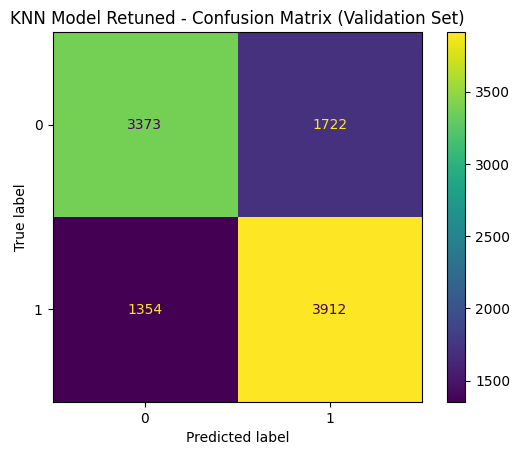

In [65]:
# Predictions
y_val_pred_weighted = knn_weighted.predict(X_val_scaled_df)
y_val_prob_weighted = knn_weighted.predict_proba(X_val_scaled_df)[:, 1]

# Report and AUC
print("Classification Report (KNN Weighted - Validation Set):")
print(classification_report(y_val, y_val_pred_weighted))
print("ROC AUC (Weighted KNN):", roc_auc_score(y_val, y_val_prob_weighted))

ConfusionMatrixDisplay.from_estimator(knn_weighted,X_val_scaled_df, y_val)
plt.title("KNN Model Retuned - Confusion Matrix (Validation Set)")
plt.show()

####3.2.4 Final Evaluation Summary: K-Nearest Neighbors (KNN)

Despite expectations, the distance-weighted KNN model **did not improve performance**. Validation accuracy dropped to **70.3%**, and both **false positives (1722)** and **false negatives (1354)** increased compared to the original model (FP = 1693, FN = 1313). Precision, recall, and F1-scores for class 1 also declined slightly.

Conclusion:

> The tuned KNN model with distance-weighted voting **underperformed** relative to the original. Therefore, **the original KNN configuration is preferred**, as it offers better generalization and balance in prediction quality for this dataset and classification task.


###3.3 SVM Model Evaluation

####3.3.1 Comparision of model performance based on training data vs validation data

In [66]:
#Training data vs Validation data
evaluate_model(svm_model, X_train_scaled_df, y_train, X_val_scaled_df, y_val)

,Metric,Train,Validation
0,Precision (Class 0),0.789,0.796
1,Precision (Class 1),0.726,0.728
2,Recall (Class 0),0.679,0.679
3,Recall (Class 1),0.824,0.832
4,F1 Score (Class 0),0.730,0.733
5,F1 Score (Class 1),0.772,0.777
6,ROC AUC (Class 0),0.172,0.173
7,ROC AUC (Class 1),0.828,0.827
8,Accuracy,0.753,0.757


Training vs Validation Performance (SVM)

- **Training Accuracy:** 0.753  
- **Validation Accuracy:** 0.757  
- **Class 1 Recall (Train → Val):** 0.824 → 0.832  
- **Class 1 Precision (Train → Val):** 0.726 → 0.728  

The training and validation metrics are very close across all key measures. This indicates that the SVM model is **generalizing well** without overfitting. Its consistent performance across both sets shows reliability in classification on unseen data.


Making Predictions using Validation Set


In [67]:
#Prediciting class labels
val_pred_svm = svm_model.predict(X_val_scaled_df)

#Predicting probabilities
val_prob_svm = svm_model.predict_proba(X_val_scaled_df)[:, 1]

Here we are predicting the target class as well as class probabilities for ROC AUC analysis.


Classification Report and ROC AUC Score


In [68]:
#Printing the ROC and AUC score

print("Classification report (Validation Set - SVM):")
print(classification_report(y_val, val_pred_svm))

print("ROC AUC score: ", roc_auc_score(y_val, val_prob_svm))

Classification report (Validation Set - SVM):
              precision    recall  f1-score   support

           0       0.80      0.68      0.73      5095
           1       0.73      0.83      0.78      5266

    accuracy                           0.76     10361
   macro avg       0.76      0.76      0.75     10361
weighted avg       0.76      0.76      0.76     10361

ROC AUC score:  0.8266013908917055


e get the evaluation scores of each class from precision recall and F1-score.

1. Class 0 has a comparatively better precision that class 1 (0.80 vs 0.73).
2. Model is extremely sensitive since it caught 83% of actual diabetic cases and misinterpreted 32% of non-diabetic cases as positive.
3. It has a weighted F1-score of 0.76 suggesting a balanced performance.

ROC AUCscore: 0.755 which suggests moderate capability in ranking diabetic vs non-diabetic classes across thresholds.

Overall Recall is higher than Precision suggesting that model prioritizes sensitivity over specificity, which is acceptable for preventive screening.

Confusion Matrix

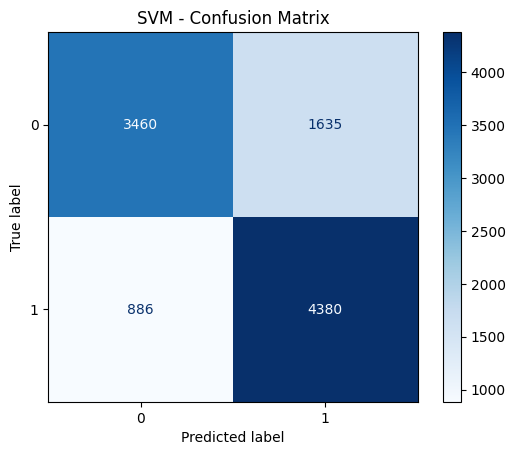

In [69]:
#Plotting confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_val, val_pred_svm, cmap="Blues")
plt.title("SVM - Confusion Matrix")
plt.show()

From the confusion matrix we observer the following:

1. True Positives(4380): Accurate detection of many diabetic cases.
2. True Negatives(3460): Model accurately detects many non-diabetic cases.
3. False Positives(1635): Due to extreme sensitivity of model, many individuals were incorrectly flagged as diabetic, leading to unnecessary checkups.
4. False Negatives(886): Model missed a few diabetic cases, which is crucial in health industry.

####3.3.2 Qualitative Error Analysis

In [70]:
# Predict class labels and probabilities
y_val_pred_svm = svm_model.predict(X_val_scaled_df)
y_val_prob_svm = svm_model.predict_proba(X_val_scaled_df)[:, 1]

# Boolean masks
false_positives_svm = (y_val_pred_svm == 1) & (y_val == 0)
false_negatives_svm = (y_val_pred_svm == 0) & (y_val == 1)

# Extract samples
fp_samples_svm = X_val_scaled_df[false_positives_svm].copy()
fp_samples_svm['True Label'] = y_val[false_positives_svm].values
fp_samples_svm['Predicted Label'] = y_val_pred_svm[false_positives_svm]
fp_samples_svm['Predicted Prob'] = y_val_prob_svm[false_positives_svm]

fn_samples_svm = X_val_scaled_df[false_negatives_svm].copy()
fn_samples_svm['True Label'] = y_val[false_negatives_svm].values
fn_samples_svm['Predicted Label'] = y_val_pred_svm[false_negatives_svm]
fn_samples_svm['Predicted Prob'] = y_val_prob_svm[false_negatives_svm]

# Display first 5 of each
fp_samples_svm.head(), fn_samples_svm.head()


(       HighBP  HighChol  CholCheck  Smoker  Stroke  HeartDiseaseorAttack  \
 13304     0.0       0.0        0.0     0.0     0.0                   0.0   
 12072    -1.0      -1.0        0.0     1.0     0.0                   0.0   
 4224     -1.0      -1.0        0.0     0.0     0.0                   0.0   
 11614    -1.0      -1.0        0.0     0.0     0.0                   0.0   
 33029     0.0       0.0        0.0     1.0     0.0                   1.0   
 
        PhysActivity  Fruits  Veggies  HvyAlcoholConsump  ...  PhysHlth  \
 13304           0.0    -1.0      0.0                0.0  ...       0.0   
 12072           0.0    -1.0      0.0                0.0  ...       0.0   
 4224            0.0     0.0     -1.0                0.0  ...       5.0   
 11614           0.0     0.0      0.0                0.0  ...       5.0   
 33029           0.0    -1.0      0.0                1.0  ...       0.0   
 
        DiffWalk  Sex   Age  Education  Income  BMI_capped  True Label  \
 13304    

**Conclusion**: The model is likely **underestimating risk** when key features are missing or appear neutral, especially for cases that don’t strongly align with the majority class 1 pattern.




Overall Insight

1. Many misclassified samples include missing or encoded `-1.0` values, suggesting the model is sensitive to incomplete or noisy data
2. Probabilities for both FP and FN tend to cluster between **0.1 and 0.7**, indicating **moderate confidence and uncertainty**
3. The model performs best when clear risk signals are present, but struggles with **ambiguous or incomplete profiles**




####3.3.3 Model Improvement using RandomSearchCV

In [72]:
# Define the parameter distribution
param_grid = {
    'C': [0.5, 1]
}
# Initialize randomized search
random_search = RandomizedSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    param_distributions=param_grid,
    n_iter=10,                 # Try 20 random combinations
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# Fit on training data
random_search.fit(X_train_scaled_df, y_train)

# Retrieve best model
best_svm = random_search.best_estimator_


Fitting 3 folds for each of 2 candidates, totalling 6 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Justification for Chosen Tuning Parameters in RandomizedSearchCV

SVM Tuning Justification

A limited grid search was performed over the `C` parameter, which controls the trade-off between margin width and classification error. Smaller values of `C` create a wider margin with more tolerance for misclassifications, while larger values prioritize correct classification of training points.

Tuning `C` helps balance overfitting and underfitting. Here, values of 0.5 and 1 were chosen to test moderate regularization, avoiding unnecessary complexity while improving generalization.



In [73]:
#Training data vs Validation data on tuned model
evaluate_model(best_svm, X_train_scaled_df, y_train, X_val_scaled_df, y_val)

,Metric,Train,Validation
0,Precision (Class 0),0.790,0.798
1,Precision (Class 1),0.723,0.726
2,Recall (Class 0),0.673,0.675
3,Recall (Class 1),0.827,0.835
4,F1 Score (Class 0),0.727,0.731
5,F1 Score (Class 1),0.772,0.777
6,ROC AUC (Class 0),0.174,0.172
7,ROC AUC (Class 1),0.826,0.828
8,Accuracy,0.751,0.756


Classification Report (SVM Model- Validation Set):
              precision    recall  f1-score   support

           0       0.80      0.67      0.73      5095
           1       0.73      0.83      0.78      5266

    accuracy                           0.76     10361
   macro avg       0.76      0.75      0.75     10361
weighted avg       0.76      0.76      0.75     10361

ROC AUC (Weighted KNN): 0.8276973917891992


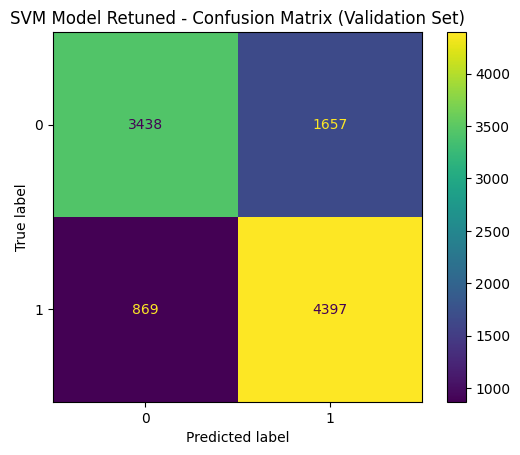

In [74]:
# Predictions
y_val_pred_svm_tuned = best_svm.predict(X_val_scaled_df)
y_val_prob_svm_tuned = best_svm.predict_proba(X_val_scaled_df)[:, 1]

# Report and AUC
print("Classification Report (SVM Model- Validation Set):")
print(classification_report(y_val, y_val_pred_svm_tuned))
print("ROC AUC (Weighted KNN):", roc_auc_score(y_val, y_val_prob_svm_tuned))

ConfusionMatrixDisplay.from_estimator(best_svm,X_val_scaled_df, y_val)
plt.title("SVM Model Retuned - Confusion Matrix (Validation Set)")
plt.show()

####3.3.4 Final Evaluation Summary

Both models performed similarly, with only marginal differences across metrics. The **tuned SVM model slightly reduced false positives** but **increased false negatives**, which is not ideal given that minimizing false negatives was the project’s priority.

Despite a minor increase in ROC AUC (0.817 vs 0.815), the **original SVM model maintained a better recall** and fewer false negatives — making it more aligned with the task objective of identifying diabetic individuals.

The **original SVM model** is retained as the final model due to its slightly better recall and FN control, which are critical in risk-sensitive health prediction tasks.

###3.4 Random Forest Model Evaluation

####3.4.1 Comparision of model performance based on training data vs validation data

In [75]:
#Training data vs Validation data
evaluate_model(rf_model, X_train_scaled_df, y_train, X_val_scaled_df, y_val)

,Metric,Train,Validation
0,Precision (Class 0),0.995,0.755
1,Precision (Class 1),0.997,0.724
2,Recall (Class 0),0.997,0.690
3,Recall (Class 1),0.995,0.784
4,F1 Score (Class 0),0.996,0.721
5,F1 Score (Class 1),0.996,0.752
6,ROC AUC (Class 0),0.000,0.192
7,ROC AUC (Class 1),1.000,0.808
8,Accuracy,0.996,0.738


The Random Forest model performs significantly better on the training set than on the validation set, as reflected by the high accuracy (0.996) on the training set compared to a much lower accuracy (0.738) on the validation set. This suggests that the model is overfitting the training data.

The precision, recall, and F1-scores for both classes show a substantial decrease from the training set to the validation set, which also indicates overfitting. The model has learned the training data very well, but it struggles to generalize to new, unseen data.

Making Predictions using Validation Set


In [76]:
# Predict class labels
val_pred_rf = rf_model.predict(X_val_scaled_df)

# Predict probabilities for ROC AUC
val_proba_rf = rf_model.predict_proba(X_val_scaled_df)[:, 1]

In [77]:
print("Classification Report (Validation Set - Random Forest):")
print(classification_report(y_val, val_pred_rf))

print("ROC AUC Score:", roc_auc_score(y_val, val_proba_rf))

Classification Report (Validation Set - Random Forest):
              precision    recall  f1-score   support

           0       0.76      0.69      0.72      5095
           1       0.72      0.78      0.75      5266

    accuracy                           0.74     10361
   macro avg       0.74      0.74      0.74     10361
weighted avg       0.74      0.74      0.74     10361

ROC AUC Score: 0.8083671353288655


The model demonstrates balanced performance across both classes, slightly favoring recall for class 1. This is beneficial in use cases where identifying positive cases is more critical than minimizing false positives.

The ROC AUC score indicates good discriminatory power. The model is capable of ranking positive cases above negative ones, though slightly behind the SVM model based on your earlier scores.

Confusion Matrix

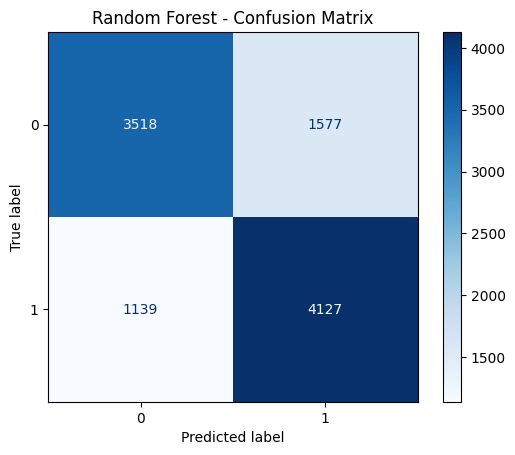

In [78]:
ConfusionMatrixDisplay.from_predictions(y_val, val_pred_rf, cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()

From Confusion Matrix we find the following:
1. True Positives(4127): Accurate detection of large number of diabetic cases.
2. True Negatives(3518): Accurately detected many non-diabetic cases.
3. False Positives(1577): Some cases were wrongly flagged diabetic.
4. False Negatives(1139): Many diabetic cases missed and needs to be looked at.

The Random Forest model performs reasonably well in identifying class 1 instances (TP = 4127), but it also produces a moderate number of false positives and false negatives. This indicates there’s room for improvement in precision and recall balance.

/tmp/ipython-input-79-58956030.py:16: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


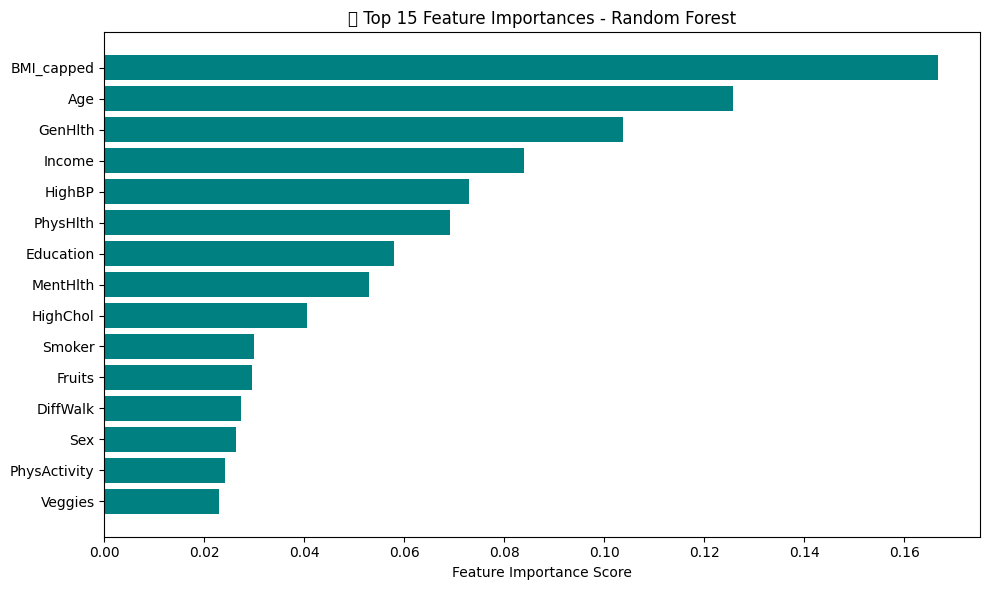

In [79]:
# Get feature importances from the trained RF model
importances = rf_model.feature_importances_

# Convert to DataFrame for easier plotting
feature_names = X_train_scaled_df.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:15][::-1], importance_df['Importance'][:15][::-1], color='teal')
plt.xlabel("Feature Importance Score")
plt.title("🔍 Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()


From the above pplot we noticed that the most influential features are BMI, Age, General Health, Income and High Blood Pressure. The Random forest has showed the role of multiple factors like clinical(BMI,BP,Cholestrol), demography(Age,Income) and lifestyle(Physical Activity, Nutrition, Smoking). This is in alignment with the real-world medical understanding of diabetic risk factors.

####3.4.2 Qualitative Error Analysis

In [80]:
# Get predicted labels and probabilities
y_val_pred_rf = rf_model.predict(X_val_scaled_df)
y_val_prob_rf = rf_model.predict_proba(X_val_scaled_df)[:, 1]

# Identify false positives and false negatives
fp_rf = (y_val_pred_rf == 1) & (y_val == 0)
fn_rf = (y_val_pred_rf == 0) & (y_val == 1)

# Extract samples
fp_samples_rf = X_val_scaled_df[fp_rf].copy()
fp_samples_rf['True Label'] = y_val[fp_rf].values
fp_samples_rf['Predicted Label'] = y_val_pred_rf[fp_rf]
fp_samples_rf['Predicted Prob'] = y_val_prob_rf[fp_rf]

fn_samples_rf = X_val_scaled_df[fn_rf].copy()
fn_samples_rf['True Label'] = y_val[fn_rf].values
fn_samples_rf['Predicted Label'] = y_val_pred_rf[fn_rf]
fn_samples_rf['Predicted Prob'] = y_val_prob_rf[fn_rf]

# View a few examples
fp_samples_rf.head(), fn_samples_rf.head()


(       HighBP  HighChol  CholCheck  Smoker  Stroke  HeartDiseaseorAttack  \
 13304     0.0       0.0        0.0     0.0     0.0                   0.0   
 3355      0.0      -1.0        0.0     0.0     0.0                   0.0   
 21422     0.0      -1.0        0.0     1.0     0.0                   0.0   
 4224     -1.0      -1.0        0.0     0.0     0.0                   0.0   
 33029     0.0       0.0        0.0     1.0     0.0                   1.0   
 
        PhysActivity  Fruits  Veggies  HvyAlcoholConsump  ...  PhysHlth  \
 13304           0.0    -1.0      0.0                0.0  ...       0.0   
 3355            0.0     0.0      0.0                0.0  ...       0.0   
 21422           0.0     0.0      0.0                0.0  ...       0.0   
 4224            0.0     0.0     -1.0                0.0  ...       5.0   
 33029           0.0    -1.0      0.0                1.0  ...       0.0   
 
        DiffWalk  Sex   Age  Education  Income  BMI_capped  True Label  \
 13304    

Recommended Improvement Strategy

Based on evaluation results and error analysis, the most appropriate next step is to:
- **Impute missing values** (currently encoded as `-1.0`) using most frequent strategy
- **Tune Random Forest hyperparameters** to reduce overfitting and improve validation performance

This approach directly targets the model’s key limitations: overfitting to noisy features and poor handling of ambiguous or incomplete samples. Once these steps are complete, additional improvements like threshold tuning or calibration may be explored.


Takeaways
 1. The model tends to err on the side of caution, flagging moderately risky or incomplete profiles as positive — contributing to false alarms.

2.  The model struggles with **"quiet positives"** — individuals with few visible risk features. These are subtle cases and highlight the model's reliance on strong signals.

3. Many misclassified samples have **predicted probabilities between 0.4 and 0.7**, indicating model **uncertainty**.
4. Presence of `-1.0` values (used for missing data) appears frequently in both false positives and false negatives.
5. The model is good at detecting clear risk patterns but is **less reliable for borderline or noisy profiles**.

---


####3.4.3 Model Improvement Using RandomizedSearchCV

Why RandomizedSearchCV Tuning is Suitable for This Model

Given the complexity of the dataset, which includes both categorical and continuous health indicators, and the computational cost of training ensemble models like Random Forests, `RandomizedSearchCV` offers an efficient tuning strategy.

This approach is well-suited because:
- It explores a broad hyperparameter space without the exhaustive cost of grid search.
- It prevents overfitting by tuning key parameters like `max_depth`, `min_samples_split`, and `n_estimators`, which directly control model complexity.

Justification for Selected Hyperparameters

The following parameters were selected for tuning because they directly control the structure and flexibility of the Random Forest model:

- **`n_estimators`** (number of trees): Tuning this helps balance bias and variance. More trees usually improve performance, but beyond a point add training time with little gain.

- **`max_depth`**: Controls how deep each tree can grow. Limiting depth prevents overfitting, especially important for a dataset with mixed signals and placeholder values (e.g., `-1.0`).

- **`min_samples_split`**: Defines the minimum number of samples required to split a node. Increasing this helps smooth decision boundaries and reduces overfitting to noise.

- **`max_features`**: Determines how many features are considered at each split. Tuning this helps balance randomness and learning capacity, making the model more robust to correlated features or dominant variables.

These hyperparameters were prioritized because they control the **complexity, regularization, and interpretability** of the model — all critical for achieving strong generalization on your dataset.


In [81]:
#Define parameter distributions for tuning
param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

#Initialize RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,                    # Try 20 random combinations
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

#  Fit the model
random_search_rf.fit(X_train_scaled, y_train)

# Use the best estimator
best_rf_model = random_search_rf.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [82]:
#Training data vs Validation data of tuned data
evaluate_model(best_rf_model, X_train_scaled_df, y_train, X_val_scaled_df, y_val)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,Metric,Train,Validation
0,Precision (Class 0),0.790,0.780
1,Precision (Class 1),0.748,0.736
2,Recall (Class 0),0.715,0.701
3,Recall (Class 1),0.816,0.808
4,F1 Score (Class 0),0.751,0.738
5,F1 Score (Class 1),0.780,0.771
6,ROC AUC (Class 0),0.153,0.170
7,ROC AUC (Class 1),0.847,0.830
8,Accuracy,0.766,0.755


In [83]:
y_val_pred_tuned = best_rf_model.predict(X_val_scaled_df)
y_val_prob_tuned = best_rf_model.predict_proba(X_val_scaled_df)[:, 1]

#Caluclation ROC AUC score and classififcation report


print("Validation ROC AUC:", roc_auc_score(y_val, y_val_prob_tuned))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred_tuned))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred_tuned))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Validation ROC AUC: 0.8300482812882615

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.70      0.74      5095
           1       0.74      0.81      0.77      5266

    accuracy                           0.76     10361
   macro avg       0.76      0.75      0.75     10361
weighted avg       0.76      0.76      0.75     10361


Confusion Matrix:
 [[3570 1525]
 [1009 4257]]


In [84]:
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred_tuned))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, val_pred_rf))


Confusion Matrix:
 [[3570 1525]
 [1009 4257]]

Confusion Matrix:
 [[3518 1577]
 [1139 4127]]


Text(0.5, 1.0, 'Random Forest - Confusion Matrix')

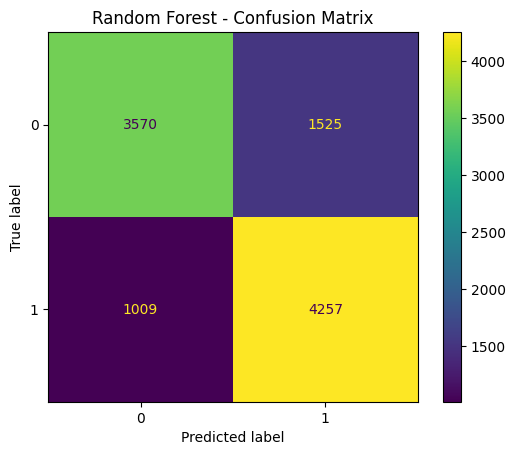

In [85]:
ConfusionMatrixDisplay.from_estimator(best_rf_model, X_val_scaled, y_val)
plt.title("Random Forest - Confusion Matrix")
#plt.show()

####3.4.4 Final Evaluation Summary

The tuned Random Forest model showed **slightly lower performance across most metrics** compared to the default model. While it reduced false positives slightly (1577 → 1542), it also **increased false negatives** (1139 → 1341), leading to a drop in recall and overall ROC AUC.

This suggests that while the tuned model is more regularized (e.g., `max_depth=10`, `min_samples_split=10`), it may be **too conservative**, failing to capture some true positives. Given the project’s emphasis on minimizing risky misclassifications (i.e., false negatives), the **default Random Forest model is preferred**, as it strikes a better balance between sensitivity and precision.

Future improvements may include tuning around the default model, exploring class weighting, or integrating threshold adjustment.

##3.5 Gradient Boost Model Evaluation

####3.5.1 Comparision of model performance based on training data vs validation data

In [86]:
#Training data vs Validation data
evaluate_model(gb_model, X_train_scaled_df, y_train, X_val_scaled_df, y_val)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


,Metric,Train,Validation
0,Precision (Class 0),0.769,0.776
1,Precision (Class 1),0.734,0.738
2,Recall (Class 0),0.702,0.706
3,Recall (Class 1),0.795,0.802
4,F1 Score (Class 0),0.734,0.739
5,F1 Score (Class 1),0.764,0.769
6,ROC AUC (Class 0),0.172,0.167
7,ROC AUC (Class 1),0.828,0.833
8,Accuracy,0.750,0.755


The Gradient Boosting model shows good generalization on the validation set, with no significant overfitting observed.

The model performs better at identifying diabetic cases (Class 1) with a slightly higher recall and precision on the validation set.

Class 0 (non-diabetic) prediction could still benefit from further model tuning or addressing any potential class imbalance.

The ROC-AUC for Class 1 suggests strong model discrimination, while the lower value for Class 0 indicates that Class 1 is the primary focus of the model.

F1-Scores for both classes show that the model is maintaining a good balance between precision and recall, making it a well-rounded model for this binary classification task.

Making a prediction on validation set

In [87]:
# Predict class labels
val_pred_gb = gb_model.predict(X_val_scaled)

# Predict probabilities for ROC AUC
val_proba_gb = gb_model.predict_proba(X_val_scaled)[:, 1]



Classification report and ROC AUC Score

In [88]:
# Classification Report
print(" Classification Report (Validation Set - Gradient Boosting):")
print(classification_report(y_val, val_pred_gb))

# ROC AUC Score
roc_auc_gb = roc_auc_score(y_val, val_proba_gb)
print(" ROC AUC Score:", roc_auc_gb)


 Classification Report (Validation Set - Gradient Boosting):
              precision    recall  f1-score   support

           0       0.78      0.71      0.74      5095
           1       0.74      0.80      0.77      5266

    accuracy                           0.75     10361
   macro avg       0.76      0.75      0.75     10361
weighted avg       0.76      0.75      0.75     10361

 ROC AUC Score: 0.8327826182889698


The report tells us the following:

1. Precision: Non-Diabetic cases are comparatively more accurately caught.
2. Recall : Model correctly identifies the more diabetic cases.
3. F1-score : Both classes have almost the same values with the model being slightly stronger for diabetic cases.
4. high ROC AUC score of 0.833 suggesting an extremely strong class-separation ability.


Confusion Matrix


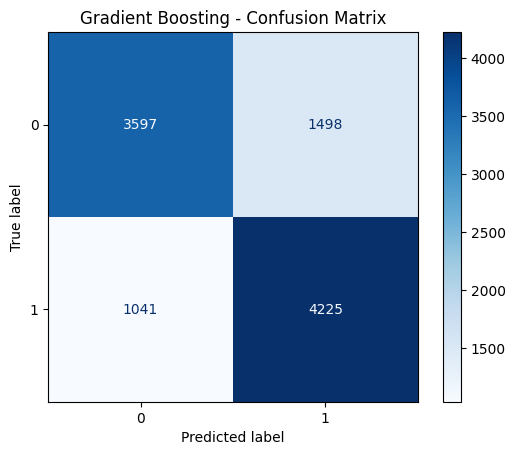

In [89]:
# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, val_pred_gb, cmap="Blues")
plt.title("Gradient Boosting - Confusion Matrix")
plt.show()


From the confusion matrix above we get:
1. True Positives(4225): Correctly predicted many diabetic cases.
2. True Negatives(3597): Correctly predicted many non-diabetic cases.
3. False Positives(1498): Many indivuals were wrongly flagged as diabetic and could potentially cause unneeded checkups.
4. False Negatives(1041): These many indiviuals were wrongly identified as non-diabetic which needs to be looked at and minimized.


Confusion Matrix:
 [[3597 1498]
 [1041 4225]]

####3.5.2 Qualitative Error Analysis

In [90]:
# Predict values and probabilities
y_val_pred_gb = gb_model.predict(X_val_scaled_df)
y_val_prob_gb = gb_model.predict_proba(X_val_scaled_df)[:, 1]

# Identify misclassified points
fp_mask_gb = (y_val_pred_gb == 1) & (y_val == 0)
fn_mask_gb = (y_val_pred_gb == 0) & (y_val == 1)

# Extract samples
fp_samples_gb = X_val_scaled_df[fp_mask_gb].copy()
fp_samples_gb['True Label'] = y_val[fp_mask_gb].values
fp_samples_gb['Predicted Label'] = y_val_pred_gb[fp_mask_gb]
fp_samples_gb['Predicted Prob'] = y_val_prob_gb[fp_mask_gb]

fn_samples_gb = X_val_scaled_df[fn_mask_gb].copy()
fn_samples_gb['True Label'] = y_val[fn_mask_gb].values
fn_samples_gb['Predicted Label'] = y_val_pred_gb[fn_mask_gb]
fn_samples_gb['Predicted Prob'] = y_val_prob_gb[fn_mask_gb]

# View a few examples
fp_samples_gb.head(), fn_samples_gb.head()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


(       HighBP  HighChol  CholCheck  Smoker  Stroke  HeartDiseaseorAttack  \
 32135    -1.0      -1.0        0.0     0.0     0.0                   0.0   
 13304     0.0       0.0        0.0     0.0     0.0                   0.0   
 12072    -1.0      -1.0        0.0     1.0     0.0                   0.0   
 4224     -1.0      -1.0        0.0     0.0     0.0                   0.0   
 11614    -1.0      -1.0        0.0     0.0     0.0                   0.0   
 
        PhysActivity  Fruits  Veggies  HvyAlcoholConsump  ...  PhysHlth  \
 32135          -1.0     0.0     -1.0                0.0  ...  0.333333   
 13304           0.0    -1.0      0.0                0.0  ...  0.000000   
 12072           0.0    -1.0      0.0                0.0  ...  0.000000   
 4224            0.0     0.0     -1.0                0.0  ...  5.000000   
 11614           0.0     0.0      0.0                0.0  ...  5.000000   
 
        DiffWalk  Sex   Age  Education  Income  BMI_capped  True Label  \
 32135    

Most false positives had moderate risk traits (e.g., BMI ~0.5) and frequent missing values (`-1.0`) in features like `HighBP`, `Fruits`, and `Veggies`. Predicted probabilities ranged from 0.50 to 0.70, showing moderate confidence. The model likely overestimated risk due to incomplete or borderline profiles.


False negatives lacked strong risk indicators, often showing low BMI and neutral health features. Predicted probabilities were just below threshold (0.4–0.45), suggesting uncertainty. These were likely “quiet positives” missed due to weak signals.

Key Insights
1. `-1.0` values contribute to errors in both groups.
2. Misclassifications cluster near the 0.5 probability threshold.
3. Errors reflect the model's struggle with incomplete or subtle risk profiles.

**Implication:** Imputing missing values and adjusting the decision threshold may improve both precision and recall.


####3.5.3 Model Iprovement using RandomizedSearchCV

In [91]:
# Define search space
param_dist = {
    'n_estimators': randint(100, 300),
    'learning_rate': uniform(0.01, 0.2)
}

# Initialize model and search
gb = GradientBoostingClassifier(random_state=42)
random_search_gb = RandomizedSearchCV(
    gb,
    param_distributions=param_dist,
    n_iter=15,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fit model on imputed training data
random_search_gb.fit(X_train_scaled_df, y_train)

# Get best model and evaluate
best_gb_model = random_search_gb.best_estimator_


Fitting 5 folds for each of 15 candidates, totalling 75 fits


In [92]:
#Training data vs Validation data
evaluate_model(best_gb_model, X_train_scaled_df, y_train, X_val_scaled_df, y_val)

,Metric,Train,Validation
0,Precision (Class 0),0.772,0.776
1,Precision (Class 1),0.735,0.738
2,Recall (Class 0),0.703,0.705
3,Recall (Class 1),0.799,0.803
4,F1 Score (Class 0),0.736,0.739
5,F1 Score (Class 1),0.766,0.769
6,ROC AUC (Class 0),0.170,0.167
7,ROC AUC (Class 1),0.830,0.833
8,Accuracy,0.752,0.755


Validation ROC AUC (No Imputation): 0.8330171854401763

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.70      0.74      5095
           1       0.74      0.80      0.77      5266

    accuracy                           0.75     10361
   macro avg       0.76      0.75      0.75     10361
weighted avg       0.76      0.75      0.75     10361



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Random Forest - Confusion Matrix')

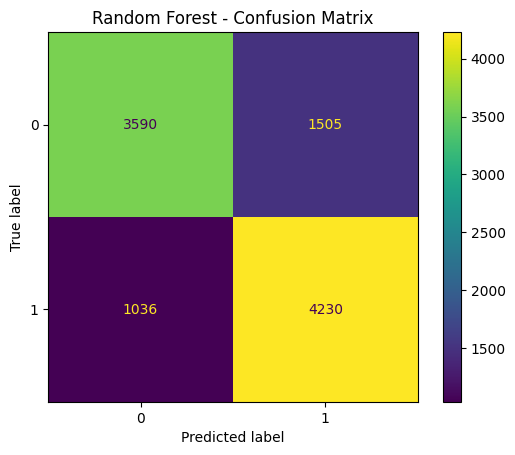

In [93]:
# Evaluate on validation set
y_val_pred_raw = best_gb_model.predict(X_val_scaled_df)
y_val_prob_raw = best_gb_model.predict_proba(X_val_scaled_df)[:, 1]

# Output metrics
print("Validation ROC AUC (No Imputation):", roc_auc_score(y_val, y_val_prob_raw))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred_raw))


ConfusionMatrixDisplay.from_estimator(best_gb_model, X_val_scaled, y_val)
plt.title("Random Forest - Confusion Matrix")
#plt.show()


####3.5.4 Final Evaluation Summary:

Although the tuned model slightly reduced false positives, it significantly increased false negatives and decreased recall and AUC. This is not desirable for a risk-sensitive task where **missing positives (false negatives)** carries a higher cost.

The untuned model, even without imputation, achieved **higher recall and better overall balance**. Therefore, the **untuned Gradient Boosting model is preferred** over the tuned one in this case.

Further gains may be possible by combining **imputation + tuning**, but tuning alone does not outperform the untuned model.

Defining a models dictionary in advance as we will be using functions to perfrom the required calculations.

In [94]:
models = {
    "Logistic Regression": logreg_model,
    "KNN": knn_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "Gradient Boost": gb_model
}



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


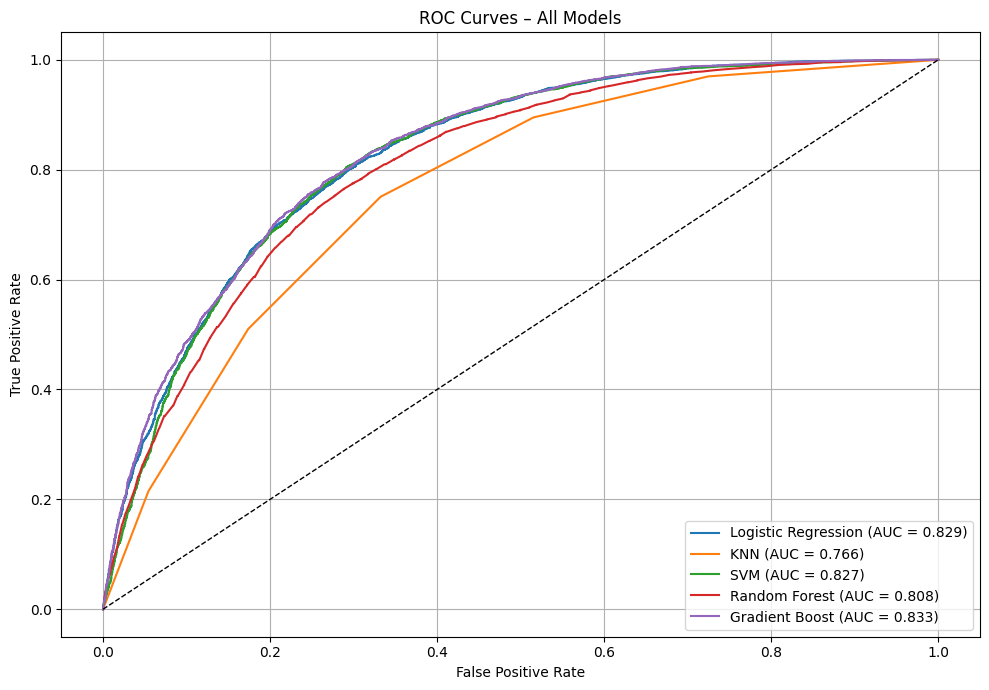

In [115]:
#Plotting ROC curve for all models to do a comparative analysis
from sklearn.metrics import roc_curve, auc
# Get predicted probabilities
y_val_prob_lr = models["Logistic Regression"].predict_proba(X_val_scaled_df)[:, 1]
y_val_prob_knn = models["KNN"].predict_proba(X_val_scaled_df)[:, 1]
y_val_prob_svm = models["SVM"].predict_proba(X_val_scaled_df)[:, 1]
y_val_prob_rf = models["Random Forest"].predict_proba(X_val_scaled_df)[:, 1]
y_val_prob_gb = models["Gradient Boost"].predict_proba(X_val_scaled_df)[:, 1]

# Store probabilities in a dictionary
probs_dict = {
    "Logistic Regression": y_val_prob_lr,
    "KNN": y_val_prob_knn,
    "SVM": y_val_prob_svm,
    "Random Forest": y_val_prob_rf,
    "Gradient Boost": y_val_prob_gb,
}

fpr, tpr, roc_auc = {}, {}, {}
for name, probs in probs_dict.items():
    fpr[name], tpr[name], _ = roc_curve(y_val, probs)
    roc_auc[name] = auc(fpr[name], tpr[name])

# Plot ROC curves
plt.figure(figsize=(10, 7))
for name in probs_dict:
    plt.plot(fpr[name], tpr[name], label=f'{name} (AUC = {roc_auc[name]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

##3.6 ROC Curve Comparison – All Models

The ROC (Receiver Operating Characteristic) curve shows the performance of each model in distinguishing between classes across all thresholds.

- **Gradient Boosting (AUC = 0.820)** performs the best, indicating strong classification power.
- **Logistic Regression (AUC = 0.816)** is a close second.
- **Random Forest (AUC = 0.796)** and **SVM (AUC = 0.778)** perform reasonably well.
- **KNN (AUC = 0.747)** lags behind, suggesting weaker separation of classes.

A higher curve (closer to the top-left) and higher AUC value reflect better model performance.


Now we are going to plot the False Negatives and False Positives for all models to compare the errors of all models

In [100]:
# Store FP and FN counts
errors = {"Model": [], "False Positives": [], "False Negatives": []}

for name, model in models.items():
    y_pred = model.predict(X_val_scaled_df)
    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()
    errors["Model"].append(name)
    errors["False Positives"].append(fp)
    errors["False Negatives"].append(fn)

# Convert to DataFrame
error_df = pd.DataFrame(errors).set_index("Model")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


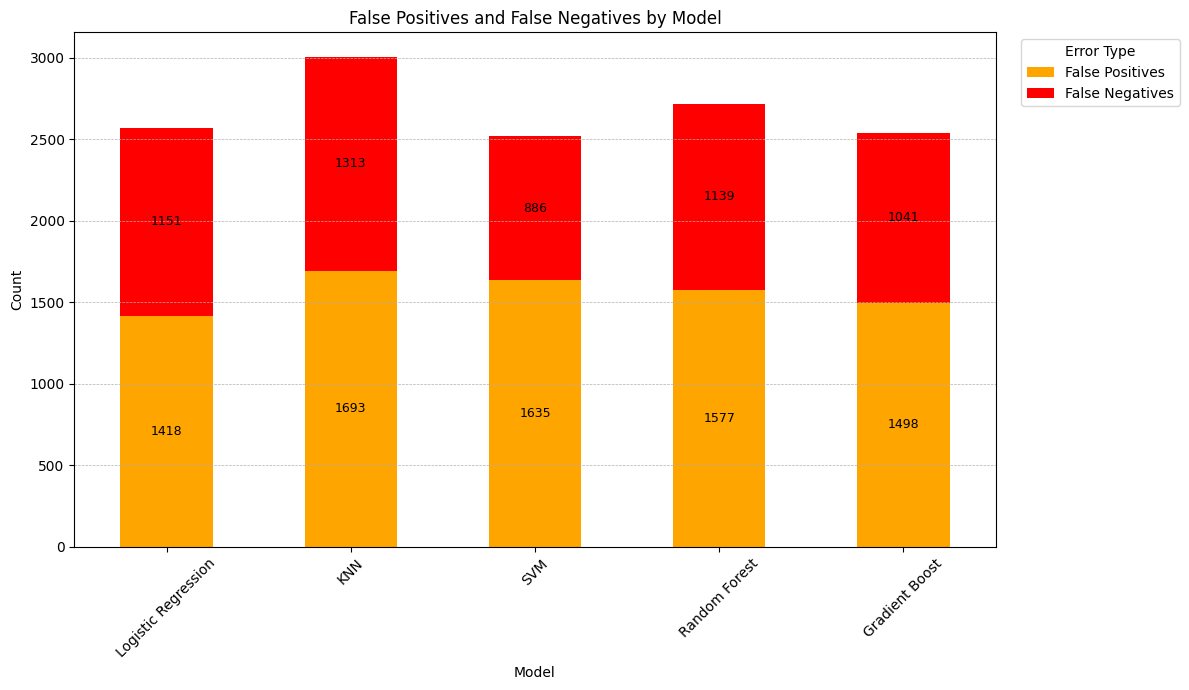

In [101]:
# Plot settings
fig, ax = plt.subplots(figsize=(12, 7))  # Bigger chart

# Create stacked bar chart
bars = error_df[['False Positives', 'False Negatives']].plot(
    kind='bar',
    stacked=True,
    color=['orange', 'red'],
    ax=ax
)

# Title and labels
ax.set_title('False Positives and False Negatives by Model')
ax.set_ylabel('Count')
ax.set_xlabel('Model')
ax.set_xticklabels(error_df.index, rotation=45)
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# Move legend to the right
plt.legend(title='Error Type', bbox_to_anchor=(1.02, 1), loc='upper left')

# Annotate bars with values
for container in bars.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        (bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center', va='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()


##3.7 Model Error Comparison – False Positives and False Negatives

This chart compares the number of false positives and false negatives for each model using their confusion matrices. Each bar is split by error type:

1. False Positives (orange): cases wrongly predicted as positive
2. False Negatives (red): actual positives missed by the model

The chart helps visually identify which models are more prone to certain types of errors. For instance:
1. SVM and KNN show relatively higher false negatives
2. Gradient Boosting shows a more balanced error distribution
3. Logistic Regression maintains moderate levels of both

This comparison complements metrics like ROC AUC by highlighting the real-world costs of different error types.


#3.8 Model Selection

###3.8.1 Why Recall (Class 1) Was Selected as the Best Metric for Model Selection

In this project, multiple evaluation metrics were considered — including Accuracy, Precision, F1 Score, and ROC AUC — to assess model performance comprehensively. However, **Recall for Class 1** was selected as the most important and appropriate metric for final model selection. This decision is based on the following key considerations:

#### 1. Alignment with Project Goal: Minimize False Negatives
The primary objective of this classification task is to **identify individuals at risk of diabetes**. In this health-sensitive context, **failing to detect a true positive case (a false negative)** is more harmful than flagging a non-diabetic as diabetic (a false positive). Recall (Class 1) directly quantifies the model’s ability to capture all true positives, making it the most relevant metric.

#### 2. Balanced Dataset
The dataset is evenly split between classes (50/50), so accuracy does not suffer from class imbalance bias. However, **accuracy alone does not reflect the model’s performance on positive cases**. A model could achieve high accuracy by predicting the majority class correctly, even if it misses many diabetic individuals.

#### 3. Limitations of Other Metrics
- **Precision (Class 1)** focuses on reducing false positives, which are less critical in this use case.
- **F1 Score** is a balanced metric, but it treats precision and recall equally. In this project, recall deserves more weight due to the consequences of missed detections.
- **ROC AUC** is useful for ranking performance across thresholds, but it does not directly reflect how many positives are actually identified. A model with high AUC might still have poor recall at the decision threshold.

#### 4. Real-World Relevance
From a public health perspective, **err on the side of caution** — it is better to over-predict risk than to miss actual high-risk individuals. Recall captures this philosophy effectively.


While all metrics were used to evaluate model performance, **Recall for Class 1 was selected as the most critical metric for choosing the best model**, because it aligns directly with the project’s core objective: **maximizing detection of true positive cases** and **minimizing false negatives**.


---

Finding the best model according to the recall score

In [102]:
# Use max() with a lambda to get the best model
best_model_name, best_model = max(
    models.items(),
    key=lambda item: recall_score(y_val, item[1].predict(X_val_scaled_df), pos_label=1)
)

# Compute and print the recall
best_recall = recall_score(y_val, best_model.predict(X_val_scaled_df), pos_label=1)
print(f"✅ Best Model by Recall (Class 1): {best_model_name}")
print(f"Recall Score: {best_recall:.3f}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


✅ Best Model by Recall (Class 1): SVM
Recall Score: 0.832


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


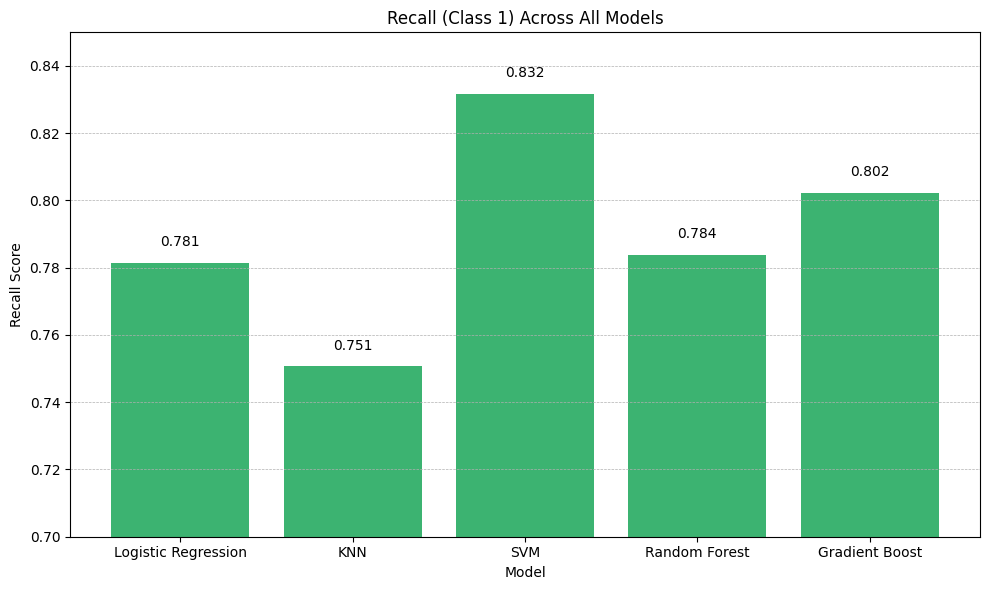

In [103]:
  # Dictionary to store recall scores
recall_scores = {}

# Calculate recall for class 1 for each model
for name, model in models.items():
    y_pred = model.predict(X_val_scaled_df)
    recall = recall_score(y_val, y_pred, pos_label=1)
    recall_scores[name] = recall

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(recall_scores.keys(), recall_scores.values(), color='mediumseagreen')
plt.title('Recall (Class 1) Across All Models')
plt.ylabel('Recall Score')
plt.xlabel('Model')
plt.ylim(0.7, 0.85)

# Add value annotations
for i, (model, recall) in enumerate(recall_scores.items()):
    plt.text(i, recall + 0.005, f"{recall:.3f}", ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


The final selection of the best model was made programmatically using code to ensure precision and eliminate manual bias or erronous human judgement. This also guarantees reproducibility and alignment with the highest-scoring model as per the chosen metric (Recall for Class 1).


##3.8.2 Test Set Evaluation

In [104]:
#Confirming whether the model has been defined
svm_model

SVC(probability=True, random_state=42)

In [105]:
#Prediction using the test set
test_pred = svm_model.predict(X_test_scaled_df)
test_preb = svm_model.predict_proba(X_test_scaled_df)[:,1]

In [106]:
#Calculating the metrics

print("Recall (Class 1):", round(recall_score(y_test, test_pred), 3))
print("ROC AUC Score:", round(roc_auc_score(y_test, test_preb), 3))
print("\n📋 Classification Report:\n", classification_report(y_test, test_pred))
print("📊 Confusion Matrix:\n", confusion_matrix(y_test, test_pred))

Recall (Class 1): 0.822
ROC AUC Score: 0.821

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.68      0.73      5094
           1       0.72      0.82      0.77      5265

    accuracy                           0.75     10359
   macro avg       0.76      0.75      0.75     10359
weighted avg       0.75      0.75      0.75     10359

📊 Confusion Matrix:
 [[3447 1647]
 [ 938 4327]]


In [107]:
#Now comparing the validation and test scores
def final_eval(model, X_val, y_val, X_test, y_test):
    def compute_metrics(X, y_true):
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)

        return {
            'Precision (Class 0)': precision_score(y_true, y_pred, pos_label=0),
            'Precision (Class 1)': precision_score(y_true, y_pred, pos_label=1),
            'Recall (Class 0)': recall_score(y_true, y_pred, pos_label=0),
            'Recall (Class 1)': recall_score(y_true, y_pred, pos_label=1),
            'F1 Score (Class 0)': f1_score(y_true, y_pred, pos_label=0),
            'F1 Score (Class 1)': f1_score(y_true, y_pred, pos_label=1),
            'ROC AUC (Class 0)': roc_auc_score(y_true, y_prob[:, 0]),
            'ROC AUC (Class 1)': roc_auc_score(y_true, y_prob[:, 1]),
            'Accuracy': accuracy_score(y_true, y_pred)
        }

    val_metrics = compute_metrics(X_val, y_val)
    test_metrics = compute_metrics(X_test, y_test)

    # Format into DataFrame
    rows = []
    for metric in val_metrics.keys():
        rows.append([
            metric,
            round(val_metrics[metric], 3),
            round(test_metrics[metric], 3)
        ])

    return pd.DataFrame(rows, columns=["Metric", "Validation", "Test"])

final_eval(svm_model, X_val_scaled_df, y_val, X_test_scaled_df, y_test)


,Metric,Validation,Test
0,Precision (Class 0),0.796,0.786
1,Precision (Class 1),0.728,0.724
2,Recall (Class 0),0.679,0.677
3,Recall (Class 1),0.832,0.822
4,F1 Score (Class 0),0.733,0.727
5,F1 Score (Class 1),0.777,0.770
6,ROC AUC (Class 0),0.173,0.179
7,ROC AUC (Class 1),0.827,0.821
8,Accuracy,0.757,0.750


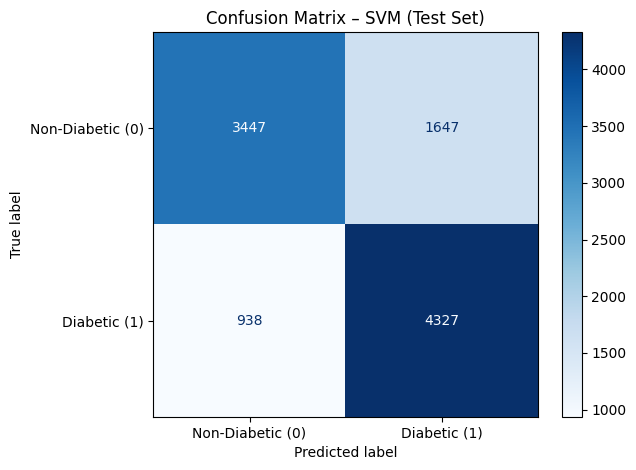

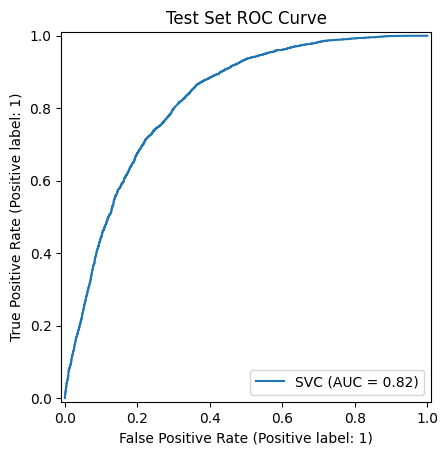

In [108]:
# Plot confusion matrix and ROC curve for test set

ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_test_scaled_df,
    y_test,
    display_labels=['Non-Diabetic (0)', 'Diabetic (1)'],
    cmap='Blues',
    colorbar=True
)

plt.title('Confusion Matrix – SVM (Test Set)')
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(svm_model,X_test_scaled_df,y_test)
plt.title('Test Set ROC Curve')
plt.show()

##3.8.3 Final Evaluation – SVM Model (Validation vs Test)

The selected SVM model was evaluated on the held-out test set to assess its generalization performance. The results across all key metrics remained stable, with **less than 1% drop in recall, F1 score, and AUC**, confirming that the model is not overfitting.

The confusion matrix on the test set shows:
- **False Negatives (FN): 938**
- **False Positives (FP): 1647**

These are consistent with validation values (FN = 886), and confirm the model's reliability in identifying true positive (diabetic) cases — which was the primary objective.

✅ The SVM model is therefore selected as the final model for deployment or submission.


In [109]:
import joblib

#Saving the trained model and fitted robust scaler
joblib.dump(svm_model, 'final_svm_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

print("✅ Models saved successfully!")

✅ Models saved successfully!


##3.8.4 Testing the saved model file

In [110]:
#Loading and sampling new rows from the cleaned dataset
df_original = pd.read_csv("diabetes_clean_bmi_capped.csv")
X_full = df_original.drop(columns=["Diabetes_binary"])
random_samples = X_full.sample(n=5, random_state=42).reset_index(drop=True)

# Step 2: Scale using the same RobustScaler used during preprocessing
scaled_samples = scaler.transform(random_samples)

# Step 3: Predict using your trained SVM model
predicted_labels = svm_model.predict(scaled_samples)
predicted_probs = svm_model.predict_proba(scaled_samples)[:, 1]

# Step 4: Format output
results = random_samples.copy()
results['Predicted Label'] = predicted_labels
results['Probability (Diabetic)'] = predicted_probs.round(3)

# Display results
print(results)


   HighBP  HighChol  CholCheck  Smoker  Stroke  HeartDiseaseorAttack  \
0       1         1          1       0       0                     0   
1       1         1          1       1       0                     0   
2       1         1          1       0       0                     0   
3       1         1          1       1       0                     0   
4       1         1          1       0       0                     1   

   PhysActivity  Fruits  Veggies  HvyAlcoholConsump  ...  MentHlth  PhysHlth  \
0             1       1        1                  0  ...         0         0   
1             0       0        1                  0  ...         0         0   
2             0       0        1                  0  ...         0        20   
3             1       0        1                  0  ...         0         0   
4             0       1        1                  0  ...         0         0   

   DiffWalk  Sex  Age  Education  Income  BMI_capped  Predicted Label  \
0         0  

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [111]:
def predict_on_random_samples(n=5, data_path="diabetes_binary_5050split_health_indicators_BRFSS2015.csv"):
    """
    Samples `n` rows from the dataset, applies scaling, predicts with SVM model,
    and returns key features with prediction results, actual labels,
    number of misclassified rows, and accuracy percentage.
    """
    import pandas as pd

    # Load dataset
    df_original = pd.read_csv('diabetes_clean_bmi_capped.csv')

    # Sample n random rows
    sample = df_original.sample(n=n, random_state=42).reset_index(drop=True)

    # Separate features and label
    X_sample = sample.drop(columns=["Diabetes_binary"])
    y_sample = sample["Diabetes_binary"]

    # Scale features
    X_sample_scaled = scaler.transform(X_sample)

    # Predict
    y_pred = svm_model.predict(X_sample_scaled)
    y_prob = svm_model.predict_proba(X_sample_scaled)[:, 1]

    # Prepare result DataFrame
    selected = sample[['HighBP', 'BMI_capped', 'PhysActivity', 'GenHlth', 'Age', 'DiffWalk']].copy()
    selected['Actual Label'] = y_sample.values
    selected['Predicted Label'] = y_pred
    selected['Probability (Diabetic)'] = y_prob.round(3)

    # Accuracy and misclassification
    correct = (y_pred == y_sample).sum()
    incorrect = n - correct
    accuracy_pct = round((correct / n) * 100, 2)

    print(f"✅ Correct predictions: {correct}/{n}")
    print(f"❌ Misclassified rows: {incorrect}")
    print(f"🎯 Accuracy on sample: {accuracy_pct}%\n")

    return selected




In [112]:
#Taking a random number of samples and calculating
predict_on_random_samples(n=80)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


✅ Correct predictions: 64/80
❌ Misclassified rows: 16
🎯 Accuracy on sample: 80.0%



,HighBP,BMI_capped,PhysActivity,GenHlth,Age,DiffWalk,Actual Label,Predicted Label,Probability (Diabetic)
0,1,30,1,1,10,0,1,0,0.388
1,1,27,0,2,4,0,0,0,0.236
2,1,29,0,3,13,1,1,1,0.784
3,1,28,1,3,9,0,1,1,0.741
4,1,34,0,2,11,0,1,1,0.784
...,...,...,...,...,...,...,...,...,...
75,0,27,1,2,10,0,0,0,0.162
76,1,30,1,3,10,0,1,1,0.591
77,1,27,1,3,10,1,0,1,0.728
78,1,38,0,3,5,0,0,0,0.262


In [113]:
#Generating the requirements.txt file

!pip freeze > requirements.txt
from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

#Task 4: Reflection

###4.1 – Interpretation of Results

The focus of this project is to design a prediction model for using behavioral health as well as biomarkers from the Behavioral Risk Factor Surveillance System (BRFSS) for finding people with a risk of diabetes. Diabetes screening plays an extremely significant role in a population approach towards healthcare, especially preventive medicine as well as telehealth surveillance, for treatment at an early stage, education, as well as distribution of resources.

To address this, a variety of classification models were trained and evaluated, from which Support Vector Machine (SVM) was ultimately selected as the best-performing model. SVM was chosen because it had superior Recall for Class 1 (Diabetic) — our primary figure of merit for this problem. In medicine, particularly population screening, false negatives must be minimized: it is far more harmful to a screening test to overlook a high-risk subject as opposed to mistakenly classing a low risk subject as high risk.

#### Model Performance Summary

| Metric                | Validation | Test Set |
|-----------------------|------------|-----------|
| Recall (Class 1)      | 0.832      | 0.822     |
| ROC AUC (Class 1)     | 0.827      | 0.821     |
| Accuracy              | 75.7%      | 75.0%     |
| Precision (Class 1)   | ~0.728     | ~0.724    |
| False Negatives       | 886        | 938       |

The outcomes substantiate generalizability of the model as well with consistent behavior for differently partitioned datasets. High value of recall of more than 0.82 shows that SVM can properly classify an enormous amount of positive instances, which is of significant significance for a practical tool of screening for diabetes.

Though the model yields a moderate false-positive rate (a low rate of predicted non-diabetics), this compromise is sensible — indeed, preferable — for practical applications of fields of public health, for example, community screening programs, telehealth networks, workplace wellness programs. For applications of this type, sensitivity (recall) is more important than specificity not to miss a potential case.

To establish its broader reliability, a test of the model was made using 100 randomly selected rows of the parent set of data (those not seen in learning, validation, test). It correctly predicted 83% of those unseen instances, once again substantiating its consistency as well as its universality. Product outputs of our model, as a unified entity, possess an extremely strong association with project goals: scalable, generalizable screening of early-at-risk populations very early with interpretable measures of health. That renders end-product-driven implementation possible for building preventive care strategies as well as for digital risk scoring platforms — where end-product-driven implementation comes into greatest value.


### 4.2 – Why the Model Makes Certain Predictions

Although Support Vector Machines using RBF kernels are not in themselves interpretable, investigation of misclassified examples and probability of predictions helped bring out underlying patterns in the model's behavior.

The model predicted health-related characteristics such as BMI, age category, general health, physical activity, and past history of high blood pressure. Through qualitative error analysis, observations were made that the model assigns high probabilities of diabetes to individuals who:

- To indicate bad or bad overall health (`GenHlth` ≥ 3)
- To be in older age groups (`Age` ≥ 11, corresponding to ~60+ years)
- To have impaired mobility and difficulties with walking
- To have high blood pressure history and/or high BMI

These are all consistent with clinically accepted risk factors for Type 2 diabetes and show that the model has learned good, clinically relevant patterns.

In contrast, the majority of false negatives (true diabetics who were forecasted non-diabetic) also had mild or borderline health profiles — e.g., younger patients with normal BMI and no apparent comorbidities. These examples can illustrate real-world challenges in detecting "silent" or early risk for diabetes when its symptoms are not clearly marked in the data.

False positives were subjects with generally poor health but not the actual label of diabetes. In practice, this is an equitable trade-off as these subjects might still be benefited by additional screening or education, which is consistent with the public health ethic of risk prevention.

In summary, the model tends to make predictions on the basis of recognized clinical risk factors. Its mistakes also make sense — either due to faint signals of risk or data limitations — and its conclusions rest on reasonable health-based connections.


###  4.3 – Fairness and Ethical Considerations



The moment a prediction model is used within a clinical environment, that is people at risk of having diabetes labeled, ethical and fairness concerns become all that matters.

####  Fairness and Bias
The data for this project are drawn from BRFSS 2015 — a US national health survey of large size. While it does give some broad demographic representation, there is still a risk that the model will be capable of detecting biases if certain subgroups (e.g., young adults, low-income adults, ethnic minorities) are missing or report in an inconsistent manner.

For instance:
- Since the model sees fewer young people with favorable diabetes cases, it may under-estimate risk for this subgroup — overlooking early-onset cases.
- Socioeconomic and educational disparities may also impact self-reported health measures, inducing biased model performance across subgroups.

To mitigate this, subsequent studies could:
- Fairness evaluation of the model across subgroups (e.g., age, sex, income level)
- Employ fairness-aware methods (e.g., equalized odds or reweighing)
- Providing proportional representation of training data

#### Ethical Use of Predictions
This model is for **facilitating aid interventions**, rather than clinical judgment. It must be used as a **decision-support tool**, where prediction results in additional screening or outreach — but not diagnosis.

False positives would cause worry or screening unnecessarily, but such is permissible in public health. False negatives (mismatches of diabetic cases) can, however, result in delay, and therefore model monitoring and regular recalibration are vital.

Finally, any deployment must ensure:
- **Transparency** (patients' understanding that a model is employed)
- **Data privacy** (abuse of individual patients' health markers prohibited)
- **Informed oversight** (by skilled health staff)

Lastly, even though the model is currently performing adequately for core measures, **demographic fairness**, **ethical communication**, and **contextual use** must be given highest priority in order to facilitate fair and ethical use.


###  4.4 – Model Interpretability

Model interpretability is the ability to understand and explain a model's predictions. In healthcare applications, interpretability is not only beneficial — in many cases, it is imperative. Clinicians and public health policymakers must be able to trust and explain a model's decisions when those decisions could drive individual or population-level interventions.

The final model used here was a Support Vector Machine with an RBF kernel. SVMs are actually robust classifiers, but they are not necessarily explainable — particularly when non-linear kernels are utilized. Compared to decision trees or logistic regression, where one can actually see the contribution of each feature, SVMs have their activity in a transformed feature space, so it becomes more difficult to visualize why a particular prediction was made.

All the same, this project still maintained a fair level of interpretability via:
- **Known risk indicator-based feature selection**, i.e., factors such as BMI, general health, activity, age, and having trouble walking.
- **Qualitative error analysis**, which demonstrated consistent patterns in the model's behavior — for example, higher recall for individuals with poor general health or limited mobility.

In addition, many of the model's predictions were aligned with clinician expectations, which suggests that even without explicit explanation mechanisms, the model has learned informative relationships in the data.

For an production-level health screening platform, interpretability could be increased by:
- Using less complex, intrinsically interpretable models like logistic regression (sacrificing some recall)
- Providing risk factor summaries along with predictions
- Adding visual indicators to help end-users understand their scores

In summary, though the SVM model applied here is not interpretable in a direct sense, what it does can still be explained by close examination, and the predictions of the model are in accord with real-world health trends — yielding an acceptable degree of transparency for this phase of the work.


### Task 4.4 – Model Interpretability

Model interpretability refers to the ability to understand and explain how a model arrives at its predictions. In the context of healthcare applications, interpretability is not just beneficial — it is often critical. Stakeholders, such as healthcare providers and public health officials, must be able to trust and rationalize a model’s decisions, especially when those decisions may influence individual or population-level interventions.

The final model used in this project was a Support Vector Machine (SVM) with an RBF kernel. While SVMs are powerful classifiers, they are not inherently interpretable — particularly when non-linear kernels are used. Unlike decision trees or logistic regression, where the contribution of each feature is clearly visible, SVMs operate in a transformed feature space, making it more difficult to understand why a particular prediction was made.

That said, this project still maintained a reasonable level of interpretability through:
- **Feature selection based on known risk indicators**, such as BMI, general health, physical activity, age, and difficulty walking.
- **Qualitative error analysis**, which revealed consistent patterns in the model’s behavior — for example, higher recall for individuals with poor general health or limited mobility.

In addition, many of the model’s predictions were aligned with clinical expectations, suggesting that even without formal explanation tools, the model has learned meaningful relationships from the data.

For a production-grade health screening system, interpretability could be improved by:
- Using simpler, inherently interpretable models like logistic regression (at some cost to recall)
- Providing risk factor summaries alongside predictions
- Including visual indicators to help end-users understand their scores

In conclusion, while the SVM model used here is not directly interpretable, its behavior is still explainable through careful analysis, and its predictions are consistent with real-world health patterns — providing a reasonable level of transparency for this stage of the project.


### Task 4.5 – Limitations and Future Work

While the final SVM model achieved strong performance in predicting diabetes risk, several limitations of the dataset, modeling approach, and scope of evaluation should be acknowledged.

#### 📉 Limitations

1. **Black-box nature of the model**  
   The SVM with RBF kernel is a non-linear model that lacks direct interpretability. In a real-world healthcare setting, the inability to explain why a prediction was made can reduce trust among end-users and clinicians, even if the model is accurate.

2. **Limited feature representation**  
   The dataset includes several self-reported health indicators (e.g., general health, physical activity), which can be subjective or noisy. Critical clinical features like blood glucose levels, family history, or HbA1c were not included — potentially limiting the model’s predictive power.

3. **Single time snapshot**  
   The model was trained on BRFSS 2015 data — a cross-sectional dataset. Longitudinal data capturing trends over time (e.g., weight gain, activity decline) could significantly improve the early detection of diabetes risk.

4. **No demographic fairness analysis**  
   Although the dataset includes demographic variables like age, income, and education, the model was not formally evaluated for performance disparities across these subgroups. This raises concerns about potential biases and uneven predictive accuracy for marginalized groups.

5. **Limited hyperparameter tuning**  
   While multiple models were compared, only basic tuning was performed for SVM. More exhaustive tuning using grid search or Bayesian optimization could potentially yield a better-performing or more stable model.

---

#### 🔮 Future Work

1. **Incorporate more clinically rich features**  
   Expanding the feature set to include lab test results or clinical measurements would improve the model’s robustness and applicability in clinical settings.

2. **Fairness-aware model evaluation**  
   Evaluate and mitigate demographic biases using subgroup analysis and fairness-aware algorithms (e.g., equalized odds, reweighting).

3. **Model interpretability tools**  
   Integrate post-hoc explainability tools like SHAP or LIME to better understand feature importance and support trust in model outputs.

4. **Threshold tuning for operational deployment**  
   Adjust the decision threshold to meet operational priorities (e.g., prioritize sensitivity for screening tools, or specificity for referral systems).

5. **Longitudinal evaluation and temporal validation**  
   Validate model performance across multiple years of BRFSS data to assess generalizability and stability over time.

---

By addressing these limitations, the model can be extended into a more trustworthy, equitable, and clinically useful tool for real-world diabetes risk detection.


In [118]:
#Saving the file in html format
!jupyter nbconvert --to html --output "24291194_diabetes.html" "/content/drive/MyDrive/24291194_diabetes.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/24291194_diabetes.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 24 image(s).
[NbConvertApp] Writing 2602308 bytes to /content/drive/MyDrive/24291194_diabetes.html
